<a href="https://colab.research.google.com/github/Katerinachristopoulou/Data_mining/blob/main/xoxha_christopoulou.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analysis of Dual Antipyretic and Cough-Suppressing Pharmaceutical Ingredients
**Research question:** Which target-binding profiles predict dual antipyretic + cough-suppressing activity in pharmaceutical ingredients, and can we identify ingredient clusters that optimise both effects simultaneously?

## Pipeline overview
1. **Pre-processing** — merge datasets,  remove zero-variance columns and missing featurws , compute class weights
2. **Clustering** — K-Means + elbow/silhouette selection → PCA visualisation
3. **Classification** — Decision Tree with SMOTE (pipeline), GridSearchCV, feature importance
4. **Regression** — Linear regression on tree-weighted activity score
5. **MapReduce** — Parallel cluster scoring and ranking

## Part 1 — Pre-processing

In [ ]:
# Cell 1 — Install & import all libraries
!pip install imbalanced-learn --quiet

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [ ]:
# Cell 2 — Load data
df_antipyretic     = pd.read_excel("/content/Dataset3 Antipyretic.xlsx")
df_coughsuppressing = pd.read_excel("/content/Dataset4 CoughSuppressing.xlsx")

print("Datasets loaded successfully.")
print(f"Antipyretic dataset  : {df_antipyretic.shape}")
print(f"Cough dataset        : {df_coughsuppressing.shape}")
display(df_antipyretic.head(3))
display(df_coughsuppressing.head(3))

Datasets loaded successfully.
Antipyretic dataset  : (1213, 381)
Cough dataset        : (1213, 381)


,Ingredient,Target1,Target2,Target3,Target4,Target5,Target6,Target7,Target8,Target9,...,Target371,Target372,Target373,Target374,Target375,Target376,Target377,Target378,Target379,Medicinal-Class
0,72,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,Antipyretic
1,119,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,1,0,not
2,176,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,1,0,1,0,not


,Ingredient,Target1,Target2,Target3,Target4,Target5,Target6,Target7,Target8,Target9,...,Target371,Target372,Target373,Target374,Target375,Target376,Target377,Target378,Target379,Medicinal-Class
0,72,0,1,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,not
1,119,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,1,0,1,0,Cough suppressing
2,176,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,1,0,1,0,not


In [ ]:
# Cell 3 — Merge datasets & assign dual labels
df = df_antipyretic.copy().rename(columns={"Medicinal-Class": "label_antipyretic"})
df_cough_labels = df_coughsuppressing[["Ingredient", "Medicinal-Class"]].rename(
    columns={"Medicinal-Class": "label_cough"})

df = df.merge(df_cough_labels, on="Ingredient", how="inner")

df["label_antipyretic"] = (df["label_antipyretic"] == "Antipyretic").astype(int)
df["label_cough"]       = (df["label_cough"] == "Cough suppressing").astype(int)
df["label_dual_action"] = ((df["label_antipyretic"] == 1) & (df["label_cough"] == 1)).astype(int)

print(f"Merged shape: {df.shape}")
print("\nLabel distribution:")
for col in ["label_antipyretic", "label_cough", "label_dual_action"]:
    print(f"  {col:25s}: {df[col].sum()} positive / {len(df)} total")

Merged shape: (1213, 383)

Label distribution:
  label_antipyretic        : 324 positive / 1213 total
  label_cough              : 152 positive / 1213 total
  label_dual_action        : 56 positive / 1213 total


In [ ]:
# Cell 4 — Check missing values & remove zero-variance columns
missing = df.isnull().sum()
print(f"Missing values: {missing[missing > 0].to_dict() or 'None'}")

target_cols = [c for c in df.columns if c.startswith("Target")]
variances = df[target_cols].var()
zero_var_cols = variances[variances == 0].index.tolist()
print(f"Zero-variance columns removed: {len(zero_var_cols)}")
df = df.drop(columns=zero_var_cols)
target_cols = [c for c in df.columns if c.startswith("Target")]
print(f"Target columns remaining     : {len(target_cols)}")

Missing values: None
Zero-variance columns removed: 0
Target columns remaining     : 379


In [ ]:
# Cell 5 — Class weights & preprocessing summary
label_names = ["label_antipyretic", "label_cough", "label_dual_action"]
class_weights = {}
for label in label_names:
    y = df[label].values
    w = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)
    class_weights[label] = dict(zip(np.unique(y), w))
    pos = df[label].sum()
    print(f"{label:25s}  pos={pos:4d}  neg={len(df)-pos:4d}  weights={class_weights[label]}")

print(f"\nFinal dataframe shape: {df.shape}")
print(f"Missing values       : {df.isnull().sum().sum()}")

label_antipyretic          pos= 324  neg= 889  weights={np.int64(0): np.float64(0.6822272215973003), np.int64(1): np.float64(1.8719135802469136)}
label_cough                pos= 152  neg=1061  weights={np.int64(0): np.float64(0.5716305372290292), np.int64(1): np.float64(3.9901315789473686)}
label_dual_action          pos=  56  neg=1157  weights={np.int64(0): np.float64(0.524200518582541), np.int64(1): np.float64(10.830357142857142)}

Final dataframe shape: (1213, 383)
Missing values       : 0


In [ ]:
# Cell 6 — Summary statistics by label group
for label, name in [
    ("label_antipyretic", "Antipyretic Only"),
    ("label_cough",       "Cough Suppressing"),
    ("label_dual_action", "Dual-Action"),
]:
    subset = df[df[label] == 1][target_cols]
    stats  = subset.describe().T[["min", "25%", "50%", "mean", "75%", "max"]]
    print(f"\n=== {name} (n={len(subset)}) — summary statistics ===")
    print(stats.to_string())


=== Antipyretic Only (n=324) — summary statistics ===
           min  25%  50%      mean  75%  max
Target1    0.0  0.0  0.0  0.098765  0.0  1.0
Target2    0.0  0.0  0.0  0.114198  0.0  1.0
Target3    0.0  0.0  0.0  0.262346  1.0  1.0
Target4    0.0  0.0  0.0  0.058642  0.0  1.0
Target5    0.0  0.0  0.0  0.052469  0.0  1.0
Target6    0.0  0.0  0.0  0.108025  0.0  1.0
Target7    0.0  0.0  0.0  0.003086  0.0  1.0
Target8    0.0  0.0  0.0  0.021605  0.0  1.0
Target9    0.0  0.0  0.0  0.015432  0.0  1.0
Target10   0.0  0.0  0.0  0.009259  0.0  1.0
Target11   0.0  0.0  0.0  0.361111  1.0  1.0
Target12   0.0  0.0  0.0  0.185185  0.0  1.0
Target13   0.0  0.0  0.0  0.006173  0.0  1.0
Target14   0.0  0.0  0.0  0.000000  0.0  0.0
Target15   0.0  0.0  0.0  0.061728  0.0  1.0
Target16   0.0  0.0  0.0  0.003086  0.0  1.0
Target17   0.0  0.0  0.0  0.095679  0.0  1.0
Target18   0.0  0.0  0.0  0.012346  0.0  1.0
Target19   0.0  0.0  0.0  0.006173  0.0  1.0
Target20   0.0  0.0  0.0  0.003086  0.0  1.0


the results indicate that the mean is the only non binary metric, it depicts the proportion of active target ingredients

## Part 2 — K-Means Clustering

In [ ]:
# Cell 7 — Clustering imports
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.decomposition import PCA
import matplotlib.gridspec as gridspec
print("Clustering libraries ready.")

Clustering libraries ready.


In [ ]:
# Cell 8 — Prepare feature matrix
X_cluster = df[target_cols].values
print(f"Feature matrix: {X_cluster.shape}")
print(f"Clustering {X_cluster.shape[0]} ingredients across {X_cluster.shape[1]} binary targets")

Feature matrix: (1213, 379)
Clustering 1213 ingredients across 379 binary targets


In [ ]:
# Cell 9 — Test k=2 to 6: inertia & silhouette scores
K_RANGE    = range(2, 7)
inertias   = []
sil_scores = []

print(f"{'k':>4}  {'Inertia':>14}  {'Silhouette Score':>18}")
print("-" * 42)

for k in K_RANGE:
    km = KMeans(n_clusters=k, init="k-means++", n_init=10, random_state=42)
    km.fit(X_cluster)
    inertias.append(km.inertia_)
    sc = silhouette_score(X_cluster, km.labels_, sample_size=500, random_state=42)
    sil_scores.append(sc)
    print(f"{k:>4}  {km.inertia_:>14.2f}  {sc:>18.4f}")

k_values = list(K_RANGE)
diffs2   = np.diff(np.diff(inertias))
elbow_k  = k_values[np.argmax(diffs2) + 1]
best_k_sil = k_values[sil_scores.index(max(sil_scores))]
print(f"\nElbow heuristic  → k = {elbow_k}")
print(f"Silhouette best  → k = {best_k_sil}")

   k         Inertia    Silhouette Score
------------------------------------------
   2        20174.36              0.0970
   3        18672.89              0.0932
   4        17628.24              0.0968
   5        16954.23              0.0934
   6        16305.42              0.1046

Elbow heuristic  → k = 3
Silhouette best  → k = 6


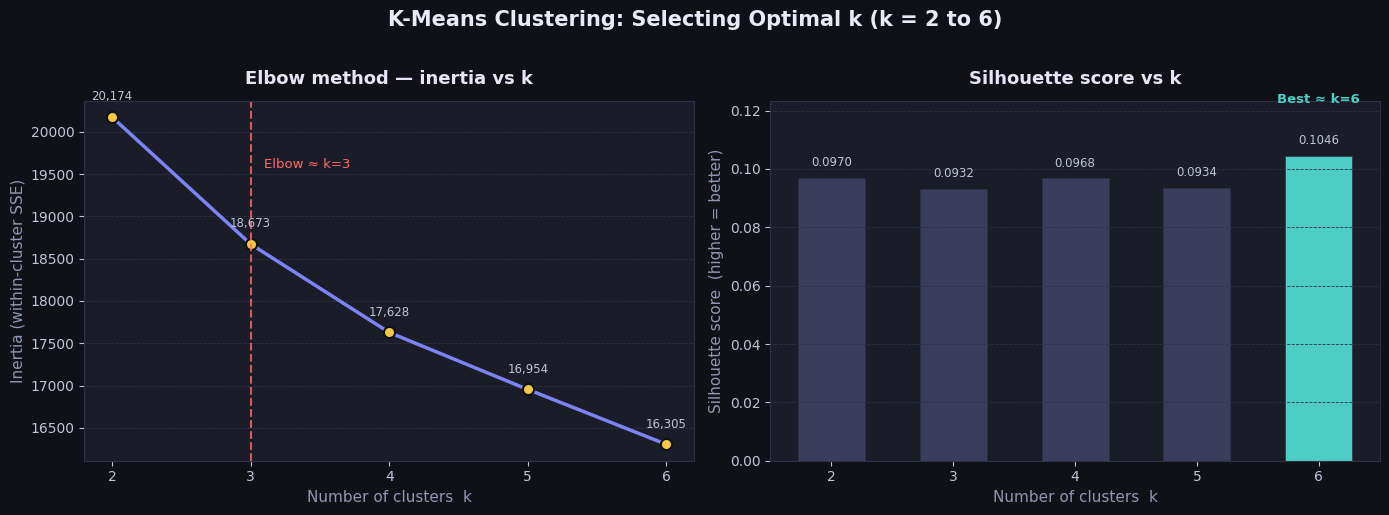


Elbow heuristic suggests k = 3
Best silhouette score suggests k = 6  (score = 0.1046)


In [ ]:
# Cell 10- Best K visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor("#0f1117")

for ax in axes:
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors="#c0c4d6", labelsize=10)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2e3148")

# ── Elbow / Inertia ──────────────────────────────────────────
axes[0].plot(k_values, inertias, color="#7c83f5", linewidth=2.5,
             marker="o", markersize=8, markerfacecolor="#f5c842",
             markeredgecolor="#0f1117", markeredgewidth=1.5)

for i, (k, v) in enumerate(zip(k_values, inertias)):
    axes[0].annotate(f"{v:,.0f}", xy=(k, v),
                     xytext=(0, 12), textcoords="offset points",
                     ha="center", fontsize=8.5, color="#c0c4d6")

axes[0].set_title("Elbow method — inertia vs k",
                  color="#e8e4f6", fontsize=13, pad=12, fontweight="bold")
axes[0].set_xlabel("Number of clusters  k", color="#9196b3", fontsize=11)
axes[0].set_ylabel("Inertia (within-cluster SSE)", color="#9196b3", fontsize=11)
axes[0].set_xticks(k_values)
axes[0].grid(axis="y", color="#2e3148", linewidth=0.6, linestyle="--")

# Mark the elbow heuristic (largest second derivative)
diffs2 = np.diff(np.diff(inertias))
elbow_k = k_values[np.argmax(diffs2) + 1]
axes[0].axvline(x=elbow_k, color="#ff6b6b", linewidth=1.5,
                linestyle="--", alpha=0.8)
axes[0].text(elbow_k + 0.1, max(inertias) * 0.97,
             f"Elbow ≈ k={elbow_k}", color="#ff6b6b", fontsize=9.5)

# ── Silhouette Score ─────────────────────────────────────────
bar_colors = ["#3a3e5c"] * len(k_values)
bar_colors[sil_scores.index(max(sil_scores))] = "#4ecdc4"

bars = axes[1].bar(k_values, sil_scores, color=bar_colors,
                   edgecolor="#2e3148", linewidth=0.5, width=0.55)

for bar, score in zip(bars, sil_scores):
    axes[1].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.003,
                 f"{score:.4f}",
                 ha="center", va="bottom", fontsize=8.5, color="#c0c4d6")

axes[1].set_title("Silhouette score vs k",
                  color="#e8e4f6", fontsize=13, pad=12, fontweight="bold")
axes[1].set_xlabel("Number of clusters  k", color="#9196b3", fontsize=11)
axes[1].set_ylabel("Silhouette score  (higher = better)", color="#9196b3", fontsize=11)
axes[1].set_xticks(k_values)
axes[1].set_ylim(0, max(sil_scores) * 1.18)
axes[1].grid(axis="y", color="#2e3148", linewidth=0.6, linestyle="--")

best_k_sil = k_values[sil_scores.index(max(sil_scores))]
axes[1].text(best_k_sil, max(sil_scores) + 0.018,
             f"Best ≈ k={best_k_sil}", color="#4ecdc4",
             ha="center", fontsize=9.5, fontweight="bold")

plt.suptitle("K-Means Clustering: Selecting Optimal k (k = 2 to 6)",
             color="#e8eaf6", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("elbow_silhouette.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()
print(f"\nElbow heuristic suggests k = {elbow_k}")
print(f"Best silhouette score suggests k = {best_k_sil}  (score = {max(sil_scores):.4f})")

as optimal k -3 has to be used validated by the elbow method. As clear seperation of clusters is not shown by silhouette score it should only be used as a validation metric. also in this case the elbow method could be easily interpreted by graph. do not use 4 because ut is significantly lower and does not uncover the structure of natural groupings

In [ ]:
# Cell 11 — Choose optimal k
print("-" * 55)
print("  Review the plots above then choose your optimal k.")
print(f"  Elbow heuristic   → k = {elbow_k}")
print(f"  Silhouette best   → k = {best_k_sil}")
print("-" * 55)
optimal_k = int(input("\nEnter your chosen k: "))
print(f"\nOptimal k set to: {optimal_k}")

-------------------------------------------------------
  Review the plots above then choose your optimal k.
  Elbow heuristic   → k = 3
  Silhouette best   → k = 6
-------------------------------------------------------

Enter your chosen k: 3

Optimal k set to: 3


In [ ]:

# Cell 12 — Run final K-Means with optimal k
#            Assign cluster labels back to the dataframe

km_final = KMeans(n_clusters=optimal_k, init="k-means++",
                  n_init=20, max_iter=500, random_state=42)
km_final.fit(X_cluster)

df["cluster_id"] = km_final.labels_

final_sil = silhouette_score(X_cluster, km_final.labels_,
                             sample_size=500, random_state=42)

print(f"K-Means fitted with k = {optimal_k}")
print(f"Final inertia        : {km_final.inertia_:,.2f}")
print(f"Final silhouette score: {final_sil:.4f}")
print(f"\nCluster assignment distribution:")
print(df["cluster_id"].value_counts().sort_index().to_string())

print(f"\nPreview — Ingredient, cluster_id, and labels:")
print(df[["Ingredient","cluster_id",
          "label_antipyretic","label_cough","label_dual_action"]].head(10).to_string())

K-Means fitted with k = 3
Final inertia        : 18,672.15
Final silhouette score: 0.0927

Cluster assignment distribution:
cluster_id
0    304
1    630
2    279

Preview — Ingredient, cluster_id, and labels:
   Ingredient  cluster_id  label_antipyretic  label_cough  label_dual_action
0          72           0                  1            0                  0
1         119           1                  0            1                  0
2         176           1                  0            0                  0
3         177           1                  0            0                  0
4         179           2                  0            0                  0
5         190           1                  1            1                  1
6         204           1                  0            0                  0
7         205           1                  0            0                  0
8         240           1                  1            1                  1
9         241        

In [ ]:
# Cell 13 — Per-cluster label breakdown
print(f"\n{'Cluster':>8}  {'Size':>6}  {'% Antipyretic':>14}  {'% Cough':>10}  {'% Dual':>8}")
print("-" * 54)

for c in sorted(df["cluster_id"].unique()):
    mask   = df["cluster_id"] == c
    size   = mask.sum()
    p_anti = df.loc[mask, "label_antipyretic"].mean() * 100
    p_cough= df.loc[mask, "label_cough"].mean() * 100
    p_dual = df.loc[mask, "label_dual_action"].mean() * 100
    print(f"{c:>8}  {size:>6}  {p_anti:>13.1f}%  {p_cough:>9.1f}%  {p_dual:>7.1f}%")


 Cluster    Size   % Antipyretic     % Cough    % Dual
------------------------------------------------------
       0     304           29.3%        6.2%      2.0%
       1     630           27.6%       15.1%      5.1%
       2     279           21.9%       13.6%      6.5%


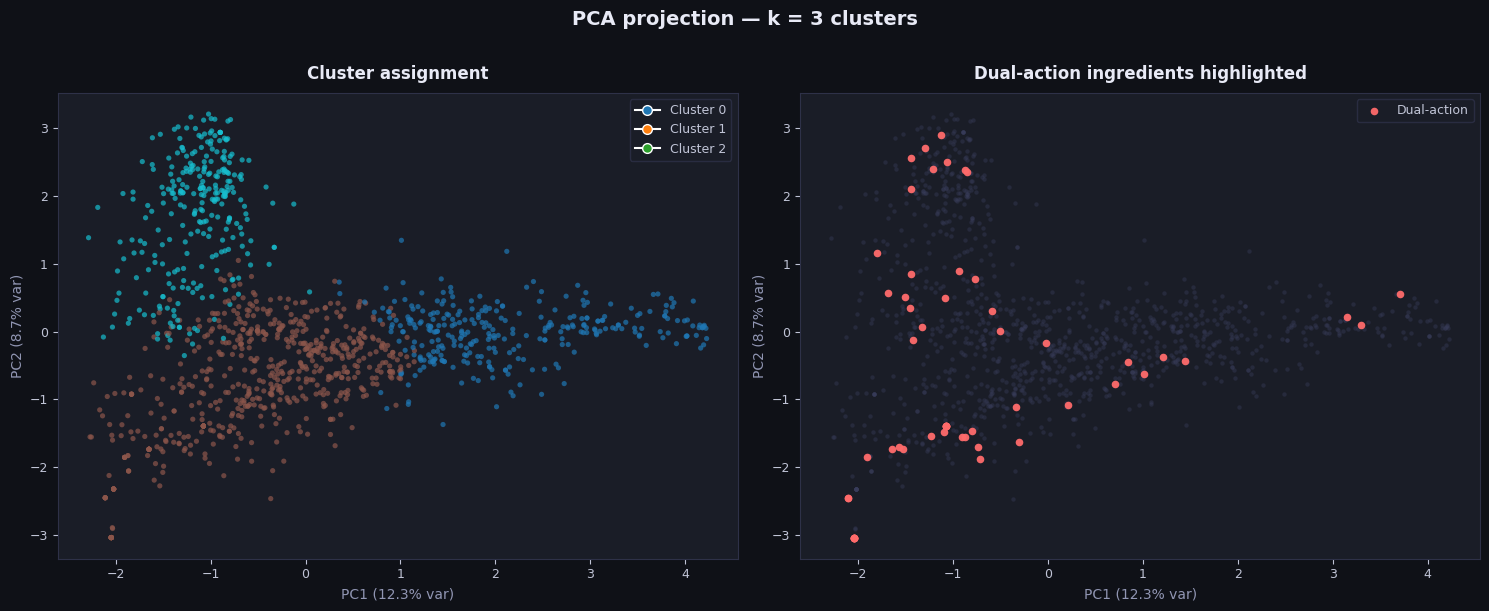


PCA explains 20.9% of variance in 2 components.

Column 'cluster_id' added to df — ready for Step 3 (Decision Tree + Regression).


In [ ]:
# Cell 14 — PCA 2D scatter: clusters coloured + label overlay

pca  = PCA(n_components=2, random_state=42)
X_2d = pca.fit_transform(X_cluster)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.patch.set_facecolor("#0f1117")

titles = ["Cluster assignment", "Dual-action ingredients highlighted"]
zorders = [df["cluster_id"].values, df["label_dual_action"].values]

# Get unique cluster IDs for the legend
cluster_ids = sorted(df["cluster_id"].unique())
# Use the same colormap as in the scatter plot for the legend
palette = plt.cm.tab10

for ax, title, color_vals in zip(axes, titles, zorders):
    ax.set_facecolor("#1a1d27")
    ax.tick_params(colors="#c0c4d6", labelsize=9)
    for spine in ax.spines.values():
        spine.set_edgecolor("#2e3148")

    if title == "Cluster assignment":
        sc = ax.scatter(X_2d[:, 0], X_2d[:, 1],
                        c=color_vals, cmap="tab10",
                        s=14, alpha=0.7, linewidths=0)
        legend_handles = [plt.Line2D([0],[0], marker="o", color="w",
                                     markerfacecolor=palette(i),
                                     markersize=7, label=f"Cluster {c}")
                          for i, c in enumerate(cluster_ids)]
        ax.legend(handles=legend_handles, facecolor="#1a1d27",
                  edgecolor="#2e3148", labelcolor="#c0c4d6", fontsize=9)
    else:
        # Background: all points grey
        ax.scatter(X_2d[:, 0], X_2d[:, 1], c="#3a3e5c",
                   s=10, alpha=0.4, linewidths=0)
        # Overlay dual-action in vivid colour
        dual_mask = df["label_dual_action"] == 1
        ax.scatter(X_2d[dual_mask, 0], X_2d[dual_mask, 1],
                   c="#ff6b6b", s=30, alpha=0.95,
                   linewidths=0, label="Dual-action")
        ax.legend(facecolor="#1a1d27", edgecolor="#2e3148",
                  labelcolor="#c0c4d6", fontsize=9)

    ax.set_title(title, color="#e8eaf6", fontsize=12,
                 pad=10, fontweight="bold")
    ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)",
                  color="#9196b3", fontsize=10)
    ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)",
                  color="#9196b3", fontsize=10)

plt.suptitle(f"PCA projection — k = {optimal_k} clusters",
             color="#e8eaf6", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("pca_clusters.png", dpi=150, bbox_inches="tight",
            facecolor="#0f1117")
plt.show()

print(f"\nPCA explains {sum(pca.explained_variance_ratio_[:2])*100:.1f}% of variance in 2 components.")
print(f"\nColumn 'cluster_id' added to df — ready for Step 3 (Decision Tree + Regression).")

clusters might be more clearly seperated but in a 2d space those clusters could not be depicted in their natural formation.

### Clustering Notes
- The elbow method evaluates the choice of k.
- Inertia values are high (sparse binary data with 379 dimensions inherently inflates SSE)-high dimentional data that could not be splitted properly
the  drop across k matters more than the absolute value.
- across clusters dual action instances are found validating its existance

## Part 3a — Decision Tree Classification

In [ ]:
# Cell 15 — Build 4-class label for classification

from sklearn.preprocessing import LabelEncoder

def assign_class(row):
    a = row["label_antipyretic"]
    c = row["label_cough"]
    if   a == 1 and c == 1: return "dual_action"
    elif a == 1 and c == 0: return "antipyretic_only"
    elif a == 0 and c == 1: return "cough_only"
    else:                   return "neither"

df["multiclass_label"] = df.apply(assign_class, axis=1)

le = LabelEncoder()
df["y_encoded"] = le.fit_transform(df["multiclass_label"])

print("Class distribution:")
dist = df["multiclass_label"].value_counts()
for cls, count in dist.items():
    pct = count / len(df) * 100
    print(f"  {cls:20s}: {count:4d}  ({pct:.1f}%)")

print(f"\nEncoding map:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# ============================================================
# CELL 15 — Feature matrix (original, UNBALANCED data)
# ============================================================
X_raw = df[target_cols].values
y_raw = df["y_encoded"].values

print(f"\nOriginal data shape: {X_raw.shape}")
print(f"Original label distribution (counts):")
for i, cls in enumerate(le.classes_):
    print(f"  {cls:20s}: {(y_raw==i).sum()}")

Class distribution:
  neither             :  793  (65.4%)
  antipyretic_only    :  268  (22.1%)
  cough_only          :   96  (7.9%)
  dual_action         :   56  (4.6%)

Encoding map:
  0 → antipyretic_only
  1 → cough_only
  2 → dual_action
  3 → neither

Original data shape: (1213, 379)
Original label distribution (counts):
  antipyretic_only    : 268
  cough_only          : 96
  dual_action         : 56
  neither             : 793


In [ ]:

# Cell 16 — Feature selection (fit once on full original data)
#           Fit once on the full original dataset to select features

from sklearn.feature_selection import SelectFromModel
from sklearn.tree import DecisionTreeClassifier

# Fit on original (unbalanced) data to get feature importances
ref_tree = DecisionTreeClassifier(
    max_depth=10, class_weight="balanced", random_state=42
)
ref_tree.fit(X_raw, y_raw) # Fit on X_raw, y_raw (original, imbalanced data)

selector    = SelectFromModel(ref_tree, threshold="mean", prefit=True)
X_sel       = selector.transform(X_raw) # Apply selector to X_raw
y_sel       = y_raw                     # y_sel is now original y_raw
sel_features = np.array(target_cols)[selector.get_support()]

print(f"Features before selection : {X_raw.shape[1]}")
print(f"Features after  selection : {X_sel.shape[1]}")
print(f"Top 10 selected: {list(sel_features[:10])}")
print(f"\nNote: X_sel and y_sel now contain the original (unbalanced) data with selected features.")

Features before selection : 379
Features after  selection : 74
Top 10 selected: [np.str_('Target3'), np.str_('Target4'), np.str_('Target6'), np.str_('Target11'), np.str_('Target12'), np.str_('Target27'), np.str_('Target29'), np.str_('Target32'), np.str_('Target33'), np.str_('Target35')]

Note: X_sel and y_sel now contain the original (unbalanced) data with selected features.


In [ ]:

# Cell 17 — GridSearchCV across all four splits
#           Uses the imblearn pipeline to apply SMOTE correctly

from sklearn.model_selection import StratifiedKFold, train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score
from imblearn.pipeline import Pipeline # Import Pipeline for imbalanced-learn
from imblearn.over_sampling import SMOTE # Import SMOTE

SPLITS      = [0.40, 0.30, 0.20, 0.10]
SPLIT_NAMES = ["60/40", "70/30", "80/20", "90/10"]

# Define the pipeline with SMOTE and Decision Tree
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(class_weight='balanced', random_state=42)) # Model step in pipeline
])

# Tight param grid — floors raised to prevent overfitting
param_grid = {
    "model__max_depth"        : [3, 5, 7, 10], # Target model step parameters
    "model__min_samples_leaf" : [10, 20, 30, 50],
    "model__min_samples_split": [20, 40, 60],
    "model__criterion"        : ["gini", "entropy"],
    "model__ccp_alpha"        : [0.0, 0.0005, 0.001, 0.002, 0.005], # ccp_alpha also for model step
}

cv_inner     = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
split_results = []

print("Running GridSearchCV for all splits with Pipeline (SMOTE + DT) — takes a few minutes...\n")

for test_size, name in zip(SPLITS, SPLIT_NAMES):

    # Split the original (feature-selected, but still imbalanced) data
    X_tr, X_te, y_tr, y_te = train_test_split(
        X_sel, y_sel,
        test_size=test_size, stratify=y_sel, random_state=42
    )

    grid = GridSearchCV(
        pipeline, # Pass the pipeline to GridSearchCV
        param_grid,
        scoring="f1_macro",
        cv=cv_inner,
        n_jobs=-1,
        verbose=0,
    )
    grid.fit(X_tr, y_tr) # SMOTE will be applied internally to X_tr within each fold

    best   = grid.best_estimator_ # This 'best' is now the fitted Pipeline
    f1_tr  = f1_score(y_tr, best.predict(X_tr), average="macro")
    f1_te  = f1_score(y_te, best.predict(X_te), average="macro")
    gap    = f1_tr - f1_te

    split_results.append({
        "name"       : name,
        "test_size"  : test_size,
        "train_n"    : len(X_tr),
        "test_n"     : len(X_te),
        "best_params": grid.best_params_,
        "cv_f1"      : grid.best_score_,
        "train_f1"   : f1_tr,
        "test_f1"    : f1_te,
        "gap"        : gap,
        "depth"      : best['model'].get_depth(), # Access model from pipeline
        "leaves"     : best['model'].get_n_leaves(), # Access model from pipeline
        "model"      : best,
        "X_tr"       : X_tr, "X_te": X_te,
        "y_tr"       : y_tr, "y_te": y_te,
    })

    status = "OK" if gap < 0.05 else "MODERATE" if gap < 0.12 else "OVERFIT"
    print(f"Split {name}")
    print(f"  Train / Test     : {len(X_tr)} / {len(X_te)}")
    print(f"  Best params      : {grid.best_params_}")
    print(f"  CV macro F1      : {grid.best_score_:.4f}")
    print(f"  Train macro F1   : {f1_tr:.4f}")
    print(f"  Test  macro F1   : {f1_te:.4f}")
    print(f"  Gap              : {gap:.4f}  [{status}]")
    print(f"  Depth / Leaves   : {best['model'].get_depth()} / {best['model'].get_n_leaves()}")
    print()


Running GridSearchCV for all splits with Pipeline (SMOTE + DT) — takes a few minutes...

Split 60/40
  Train / Test     : 727 / 486
  Best params      : {'model__ccp_alpha': 0.0, 'model__criterion': 'entropy', 'model__max_depth': 7, 'model__min_samples_leaf': 30, 'model__min_samples_split': 20}
  CV macro F1      : 0.3009
  Train macro F1   : 0.3421
  Test  macro F1   : 0.2594
  Gap              : 0.0827  [MODERATE]
  Depth / Leaves   : 7 / 28

Split 70/30
  Train / Test     : 849 / 364
  Best params      : {'model__ccp_alpha': 0.005, 'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 20}
  CV macro F1      : 0.3076
  Train macro F1   : 0.3702
  Test  macro F1   : 0.3062
  Gap              : 0.0640  [MODERATE]
  Depth / Leaves   : 9 / 22

Split 80/20
  Train / Test     : 970 / 243
  Best params      : {'model__ccp_alpha': 0.0, 'model__criterion': 'gini', 'model__max_depth': 7, 'model__min_samples_leaf': 50, 'model__min_samples

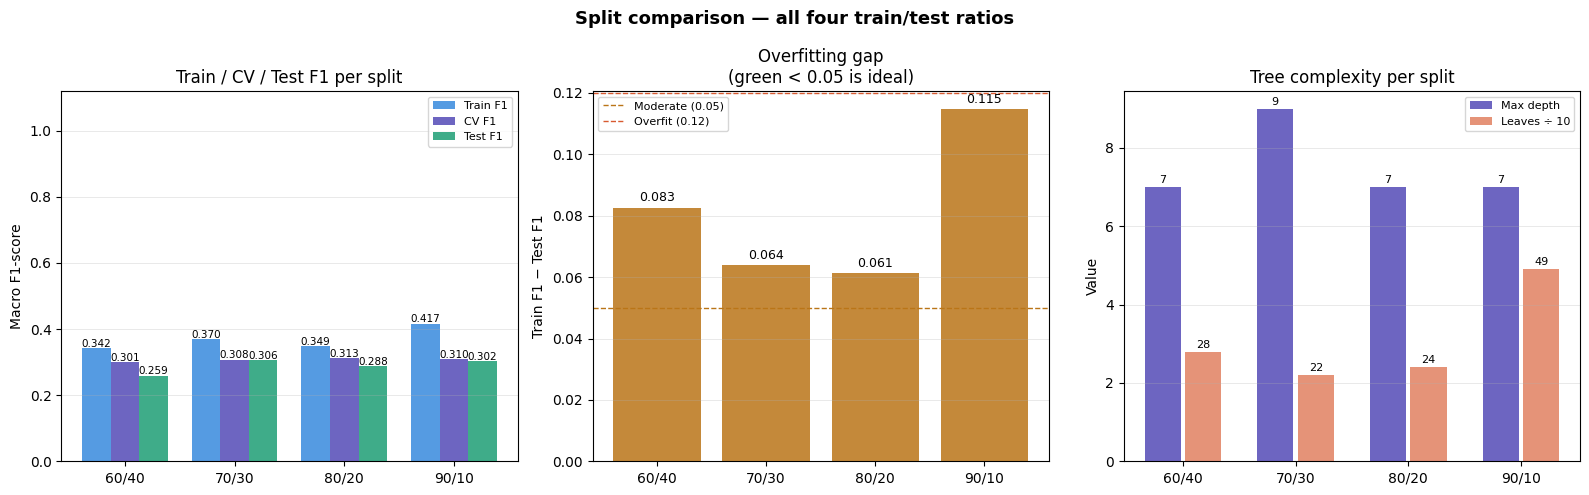


Instructions:
  Choose the split where:
  1. Test F1 is highest
  2. Gap (Train − Test) is smallest  (green bar = best)
  3. Tree complexity is not excessive


In [ ]:

# Cell 18 — Visualise split comparison
#           Three panels: F1 bars | Gap | Tree complexity

names     = [r["name"]    for r in split_results]
cv_f1s    = [r["cv_f1"]   for r in split_results]
train_f1s = [r["train_f1"]for r in split_results]
test_f1s  = [r["test_f1"] for r in split_results]
gaps      = [r["gap"]     for r in split_results]
depths    = [r["depth"]   for r in split_results]
leaves    = [r["leaves"]  for r in split_results]

x     = np.arange(len(names))
width = 0.26

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Split comparison — all four train/test ratios",
             fontsize=13, fontweight="bold")

# --- Panel 1: F1 grouped bars ---
ax = axes[0]
b1 = ax.bar(x - width, train_f1s, width, label="Train F1", color="#378ADD", alpha=0.85)
b2 = ax.bar(x,         cv_f1s,    width, label="CV F1",    color="#534AB7", alpha=0.85)
b3 = ax.bar(x + width, test_f1s,  width, label="Test F1",  color="#1D9E75", alpha=0.85)
for bars, vals in [(b1, train_f1s), (b2, cv_f1s), (b3, test_f1s)]:
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.004,
                f"{v:.3f}", ha="center", fontsize=7.5)
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylim(0, 1.12); ax.set_ylabel("Macro F1-score")
ax.set_title("Train / CV / Test F1 per split")
ax.legend(fontsize=8); ax.grid(axis="y", linewidth=0.4, alpha=0.5)

# --- Panel 2: Gap (overfitting) ---
ax2 = axes[1]
gap_colors = ["#D85A30" if g > 0.12 else "#BA7517" if g > 0.05 else "#1D9E75"
              for g in gaps]
b4 = ax2.bar(names, gaps, color=gap_colors, alpha=0.85)
for bar, v in zip(b4, gaps):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
             f"{v:.3f}", ha="center", fontsize=9)
ax2.axhline(0.05,  color="#BA7517", linestyle="--", linewidth=1,
            label="Moderate (0.05)")
ax2.axhline(0.12,  color="#D85A30", linestyle="--", linewidth=1,
            label="Overfit (0.12)")
ax2.set_ylabel("Train F1 − Test F1")
ax2.set_title("Overfitting gap\n(green < 0.05 is ideal)")
ax2.legend(fontsize=8); ax2.grid(axis="y", linewidth=0.4, alpha=0.5)

# --- Panel 3: Tree complexity ---
ax3 = axes[2]
ax3.bar(x - 0.18, depths, 0.32, label="Max depth",  color="#534AB7", alpha=0.85)
ax3.bar(x + 0.18, [l/10 for l in leaves], 0.32,
        label="Leaves ÷ 10", color="#D85A30", alpha=0.65)
for i, (d, l) in enumerate(zip(depths, leaves)):
    ax3.text(i - 0.18, d + 0.1, str(d), ha="center", fontsize=8)
    ax3.text(i + 0.18, l/10 + 0.1, str(l), ha="center", fontsize=8)
ax3.set_xticks(x); ax3.set_xticklabels(names)
ax3.set_ylabel("Value"); ax3.set_title("Tree complexity per split")
ax3.legend(fontsize=8); ax3.grid(axis="y", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig("split_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nInstructions:")
print("  Choose the split where:")
print("  1. Test F1 is highest")
print("  2. Gap (Train − Test) is smallest  (green bar = best)")
print("  3. Tree complexity is not excessive")


the configuration choosen purely by those rules was explained by the graphs and the stats later in the code 70/30 that was midly a moderatelly train -test performing model to avoid an overfitting configuration

Synthetic Minority Over-sampling Technique (SMOTE) is a popular machine learning algorithm used to address imbalanced datasets by generating synthetic samples for the minority class. Instead of mere duplication, it creates new, similar data points via interpolation between existing minority neighbors, helping to improve classification performance without losing information. It was used for less overfitting and better recall

Available splits: 60/40  |  70/30  |  80/20  |  90/10
Enter your chosen split: 70/30

Chosen split  : 70/30
Best ccp_alpha: 0.004296


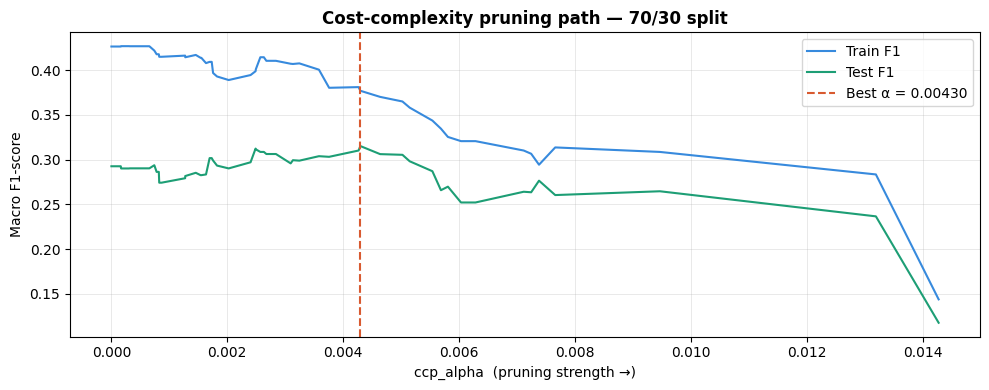


=== Final model (Pipeline with SMOTE) — 70/30 split ===
  Train macro F1 : 0.3770
  Test  macro F1 : 0.3153
  Gap            : 0.0618  MODERATE
  Tree depth     : 9
  Num leaves     : 23


In [ ]:
# Cell 19 — USER INPUT: choose split & train final model

print("Available splits: 60/40  |  70/30  |  80/20  |  90/10")
chosen = input("Enter your chosen split: ").strip()

valid = {"60/40", "70/30", "80/20", "90/10"}
if chosen not in valid:
    raise ValueError(f"Must be one of {valid}")

rec = next(r for r in split_results if r["name"] == chosen)

X_tr_f = rec["X_tr"]; X_te_f = rec["X_te"]
y_tr_f = rec["y_tr"]; y_te_f = rec["y_te"]

# ---- CCP pruning path on chosen split using the pipeline ----
# Extract base Decision Tree parameters from best_params, excluding ccp_alpha
base_params = {k.replace('model__', ''): v for k, v in rec["best_params"].items() if not k.endswith('ccp_alpha')}

# Create a temporary DecisionTreeClassifier to get the pruning path
temp_dt = DecisionTreeClassifier(**base_params, class_weight="balanced", random_state=42)

# Fit a SMOTE-resampled version of the training data to get the pruning path
# This simulates what happens inside the pipeline during cross-validation.
smote_temp = SMOTE(random_state=42)
X_tr_f_sm, y_tr_f_sm = smote_temp.fit_resample(X_tr_f, y_tr_f)

path   = temp_dt.cost_complexity_pruning_path(X_tr_f_sm, y_tr_f_sm)
alphas = path.ccp_alphas[:-1] # Exclude max alpha that prunes all leaves

alpha_f1_te = []
for a in alphas:
    # Create a pipeline for each alpha to ensure SMOTE is applied correctly
    pruning_pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier(
            **base_params, ccp_alpha=a, class_weight="balanced", random_state=42
        ))
    ])
    pruning_pipeline.fit(X_tr_f, y_tr_f) # Fit pipeline on original training data
    alpha_f1_te.append(f1_score(y_te_f, pruning_pipeline.predict(X_te_f), average="macro"))

best_alpha_idx = np.argmax(alpha_f1_te)
best_alpha = alphas[best_alpha_idx] if len(alphas) > 0 else 0.0 # Handle case with no alphas
print(f"\nChosen split  : {chosen}")
print(f"Best ccp_alpha: {best_alpha:.6f}")

# ---- Plot pruning path ----
alpha_f1_tr = []
for a in alphas:
    pruning_pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('model', DecisionTreeClassifier(
            **base_params, ccp_alpha=a, class_weight="balanced", random_state=42
        ))
    ])
    pruning_pipeline.fit(X_tr_f, y_tr_f)
    alpha_f1_tr.append(f1_score(y_tr_f, pruning_pipeline.predict(X_tr_f), average="macro"))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(alphas, alpha_f1_tr, label="Train F1", color="#378ADD", linewidth=1.5)
ax.plot(alphas, alpha_f1_te, label="Test F1",  color="#1D9E75", linewidth=1.5)
ax.axvline(best_alpha, color="#D85A30", linestyle="--",
           label=f"Best α = {best_alpha:.5f}")
ax.set_xlabel("ccp_alpha  (pruning strength →)")
ax.set_ylabel("Macro F1-score")
ax.set_title(f"Cost-complexity pruning path — {chosen} split", fontweight="bold")
ax.legend(); ax.grid(linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("pruning_path.png", dpi=150, bbox_inches="tight")
plt.show()

# ---- Train final model (the pipeline) ----
# Get the best parameters, update ccp_alpha to the optimized one
final_best_params = rec["best_params"].copy()
final_best_params["model__ccp_alpha"] = best_alpha

final_model = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42,
        **{k.replace('model__', ''): v for k, v in final_best_params.items() if k.startswith('model__')}
    ))
])

final_model.fit(X_tr_f, y_tr_f) # Fit the pipeline on original training data

y_pred_tr = final_model.predict(X_tr_f)
y_pred_te = final_model.predict(X_te_f)

f1_tr_fin = f1_score(y_tr_f, y_pred_tr, average="macro")
f1_te_fin = f1_score(y_te_f, y_pred_te, average="macro")
gap_fin   = f1_tr_fin - f1_te_fin

print(f"\n=== Final model (Pipeline with SMOTE) — {chosen} split ===")
print(f"  Train macro F1 : {f1_tr_fin:.4f}")
print(f"  Test  macro F1 : {f1_te_fin:.4f}")
print(f"  Gap            : {gap_fin:.4f}  "
      f"{'OK' if gap_fin < 0.05 else 'MODERATE' if gap_fin < 0.12 else 'OVERFIT'}")
print(f"  Tree depth     : {final_model['model'].get_depth()}") # Access model from pipeline
print(f"  Num leaves     : {final_model['model'].get_n_leaves()}") # Access model from pipeline


=== Classification report — TRAIN (70/30) ===
                  precision    recall  f1-score   support

antipyretic_only       0.34      0.49      0.40       188
      cough_only       0.28      0.46      0.35        67
     dual_action       0.12      0.49      0.19        39
         neither       0.79      0.44      0.56       555

        accuracy                           0.45       849
       macro avg       0.38      0.47      0.38       849
    weighted avg       0.62      0.45      0.49       849

=== Classification report — TEST (70/30) ===
                  precision    recall  f1-score   support

antipyretic_only       0.28      0.41      0.33        80
      cough_only       0.23      0.41      0.30        29
     dual_action       0.06      0.24      0.10        17
         neither       0.75      0.41      0.53       238

        accuracy                           0.40       364
       macro avg       0.33      0.37      0.32       364
    weighted avg       0.58      0

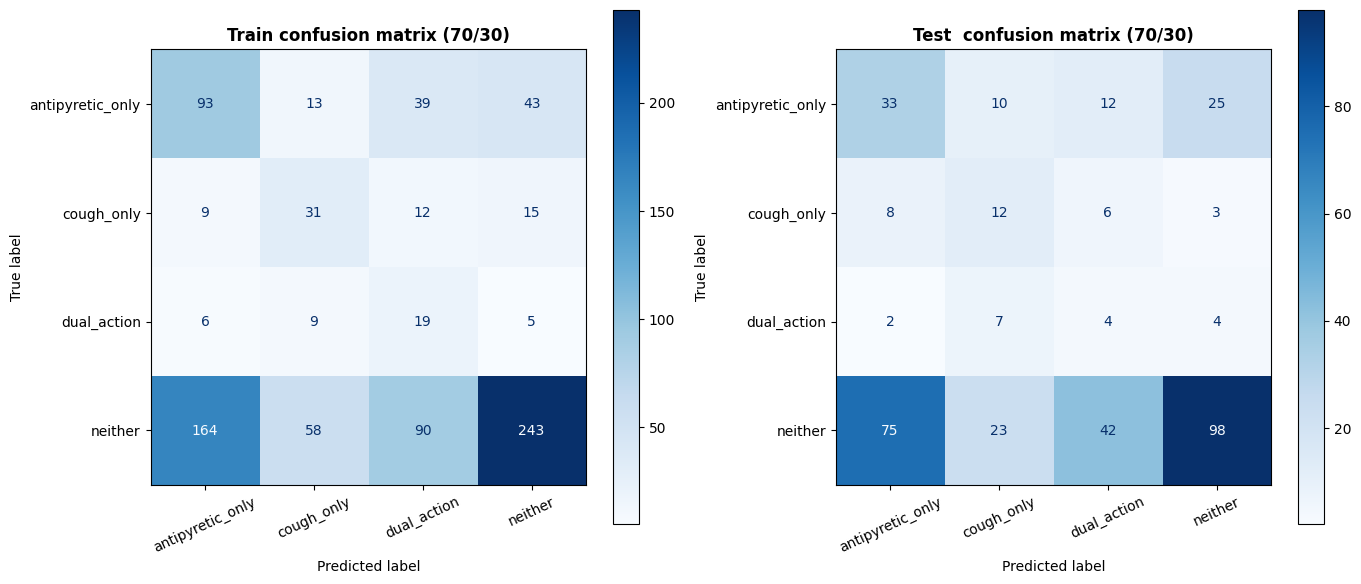

In [ ]:

# Cell 20 — Classification report + confusion matrix

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

class_names = list(le.classes_)

print(f"=== Classification report — TRAIN ({chosen}) ===")
print(classification_report(y_tr_f, y_pred_tr, target_names=class_names))

print(f"=== Classification report — TEST ({chosen}) ===")
print(classification_report(y_te_f, y_pred_te, target_names=class_names))

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, y_true, y_pred, title in [
    (axes[0], y_tr_f, y_pred_tr, f"Train confusion matrix ({chosen})"),
    (axes[1], y_te_f, y_pred_te, f"Test  confusion matrix ({chosen})"),
]:
    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=class_names)\
        .plot(ax=ax, colorbar=True, cmap="Blues", xticks_rotation=25)
    ax.set_title(title, fontweight="bold")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

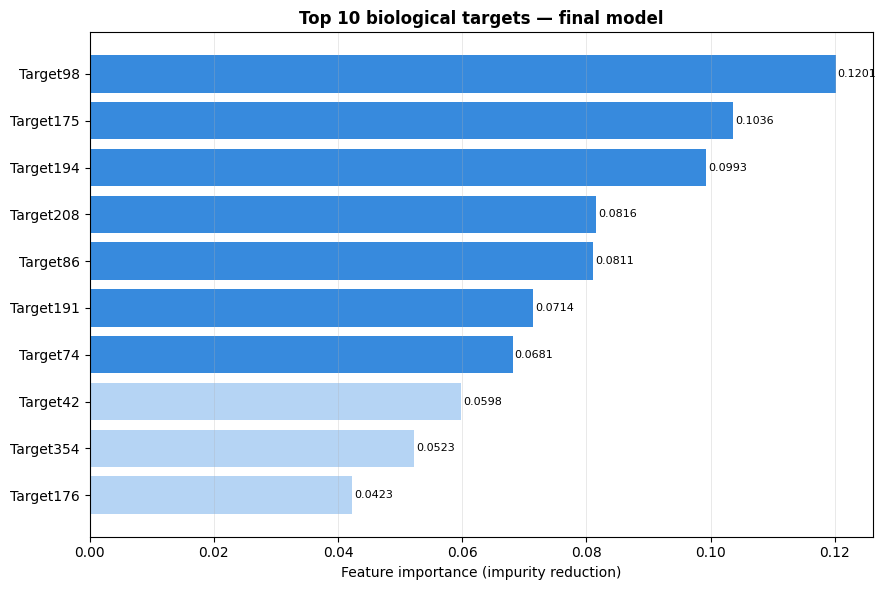

Top 10 targets:
   1. Target98      0.120091
   2. Target175     0.103581
   3. Target194     0.099319
   4. Target208     0.081600
   5. Target86      0.081095
   6. Target191     0.071412
   7. Target74      0.068089
   8. Target42      0.059809
   9. Target354     0.052273
  10. Target176     0.042297


In [ ]:
importances  = final_model['model'].feature_importances_
sorted_idx   = np.argsort(importances)[::-1]
top_n        = 10 # Modified to plot only the top 10 features
top_idx      = sorted_idx[:top_n]
top_names    = [sel_features[i] for i in top_idx]
top_vals     = importances[top_idx]

threshold    = top_vals[0] * 0.5
bar_colors   = ["#378ADD" if v >= threshold else "#B5D4F4" for v in top_vals]

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(top_names[::-1], top_vals[::-1], color=bar_colors[::-1])
for i, (name, val) in enumerate(zip(top_names[::-1], top_vals[::-1])):
    ax.text(val + 0.0003, i, f"{val:.4f}", va="center", fontsize=8)
ax.set_xlabel("Feature importance (impurity reduction)")
ax.set_title(f"Top {top_n} biological targets — final model", fontweight="bold")
ax.grid(axis="x", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 10 targets:")
for i, (name, val) in enumerate(zip(top_names[:10], top_vals[:10]), 1):
    print(f"  {i:2d}. {name:12s}  {val:.6f}")

=== Decision rules — first 3 levels ===
|--- Target98 <= 0.50
|   |--- Target175 <= 0.50
|   |   |--- Target208 <= 0.50
|   |   |   |--- Target354 <= 0.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |   |--- Target354 >  0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- Target208 >  0.50
|   |   |   |--- Target74 <= 0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- Target74 >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |--- Target175 >  0.50
|   |   |--- Target194 <= 0.50
|   |   |   |--- Target191 <= 0.50
|   |   |   |   |--- class: 3
|   |   |   |--- Target191 >  0.50
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Target194 >  0.50
|   |   |   |--- class: 3
|--- Target98 >  0.50
|   |--- Target194 <= 0.50
|   |   |--- Target86 <= 0.50
|   |   |   |--- Target74 <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Target74 >  0.50
|   |   |   |   |--- class: 0
|   |   |--- Target86 >  

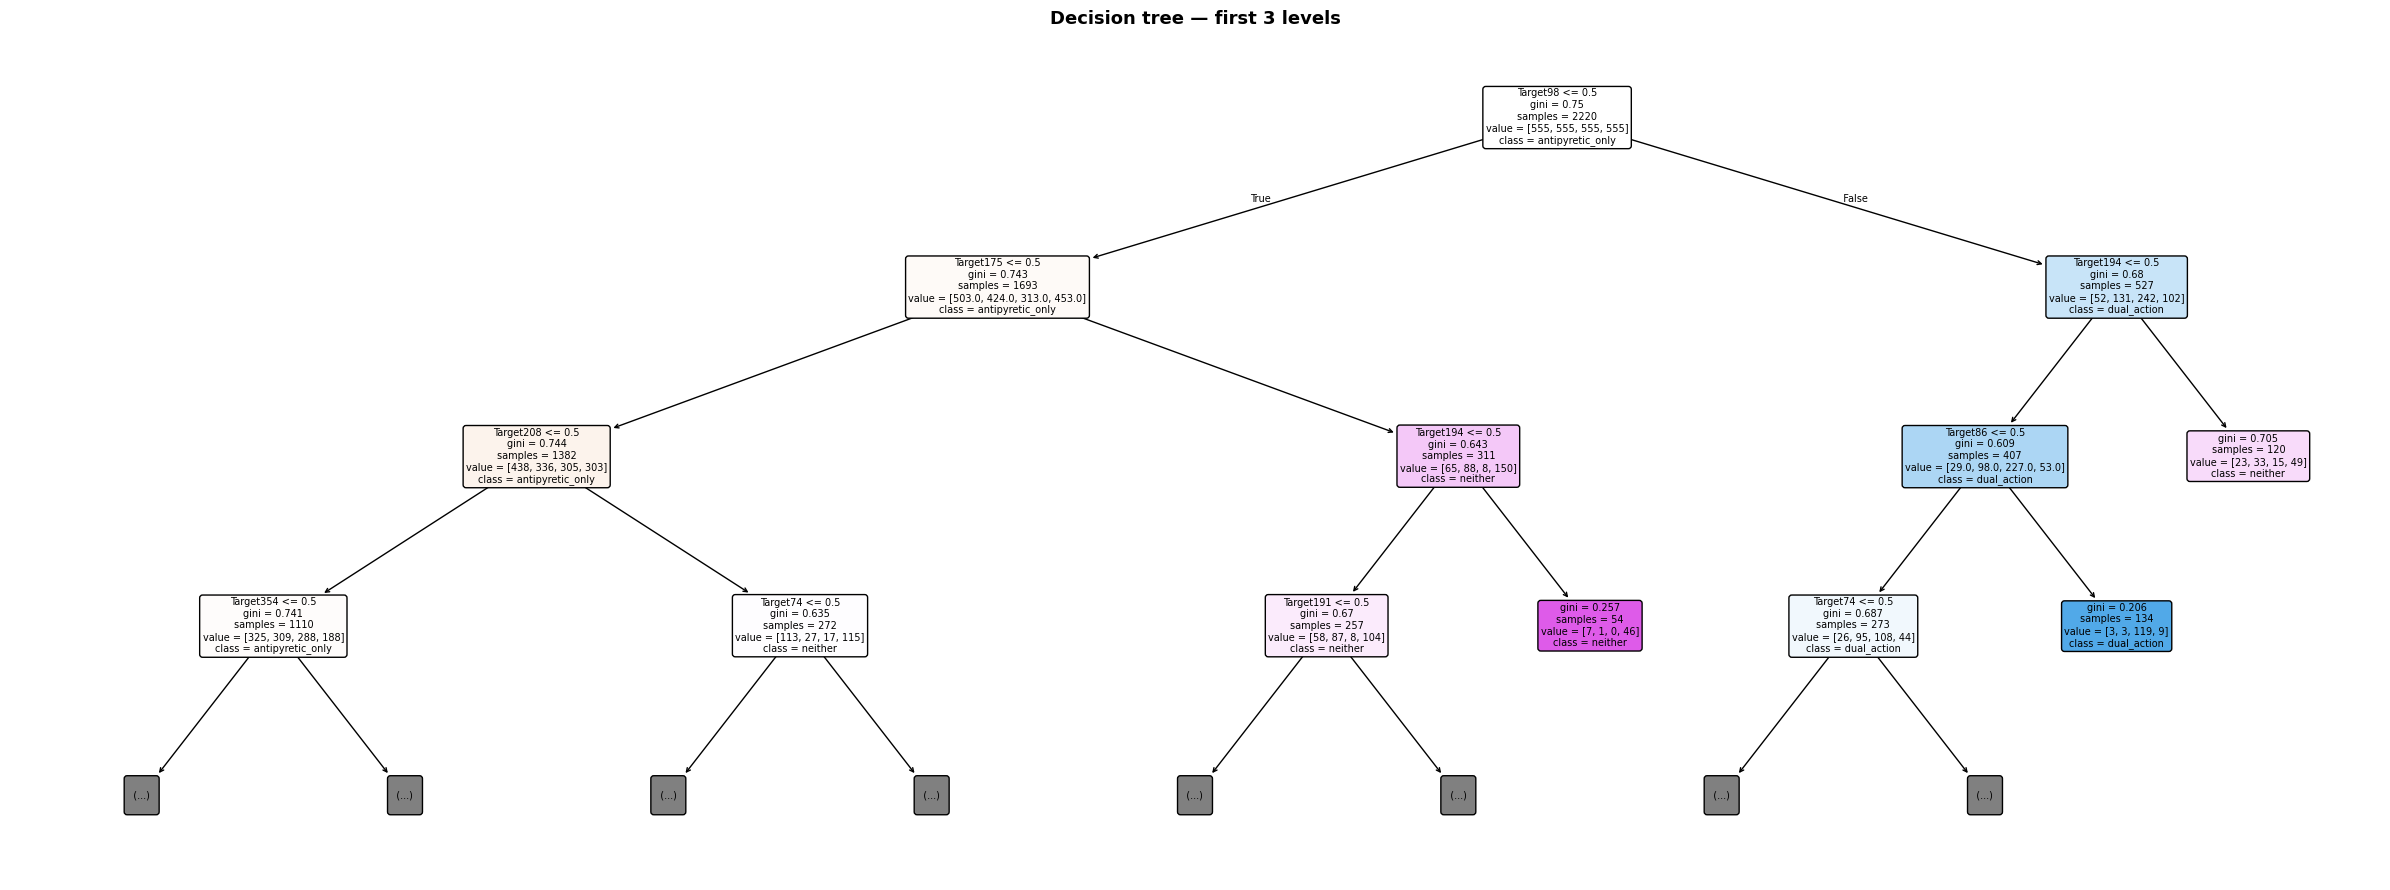

In [ ]:
# Cell 22 — Decision rules (text + visual tree, depth 3)
from sklearn.tree import export_text, plot_tree

rules = export_text(final_model['model'], feature_names=list(sel_features), max_depth=3)
print("=== Decision rules — first 3 levels ===")
print(rules)

with open("decision_rules_full.txt", "w") as f:
    f.write(export_text(final_model['model'], feature_names=list(sel_features)))
print("Full rules saved to decision_rules_full.txt")

fig, ax = plt.subplots(figsize=(24, 9))
plot_tree(
    final_model['model'],
    feature_names = list(sel_features),
    class_names   = class_names,
    filled        = True,
    rounded       = True,
    max_depth     = 3,
    fontsize      = 7,
    ax            = ax,
)
ax.set_title("Decision tree — first 3 levels", fontweight="bold", fontsize=13)
plt.tight_layout()
plt.savefig("decision_tree_plot.png", dpi=150, bbox_inches="tight")
plt.show()

=== 10-fold stratified CV — final model ===
  Fold  1: 0.2384  ███████
  Fold  2: 0.2403  ███████
  Fold  3: 0.2422  ███████
  Fold  4: 0.3361  ██████████
  Fold  5: 0.3140  █████████
  Fold  6: 0.2275  ██████
  Fold  7: 0.2444  ███████
  Fold  8: 0.2378  ███████
  Fold  9: 0.2837  ████████
  Fold 10: 0.3198  █████████

  Mean  : 0.2684
  Std   : 0.0389
  Range : 0.2275 – 0.3361


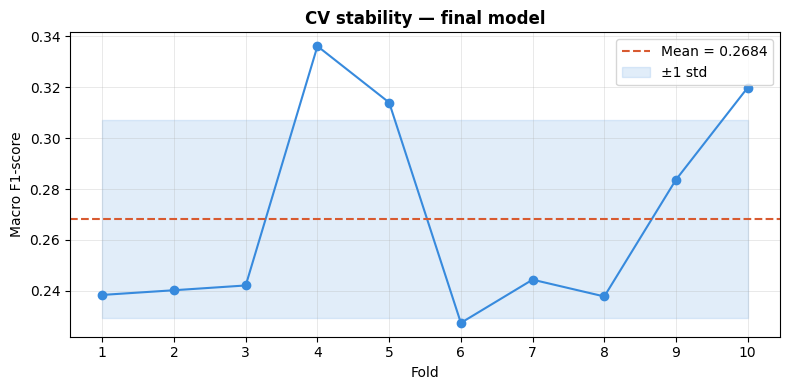

In [ ]:
# Cell 23 — 10-fold CV stability check
# NOTE: We wrap final_model in a pipeline with SMOTE to avoid leakage.
from sklearn.model_selection import cross_val_score, StratifiedKFold
from imblearn.pipeline import Pipeline

cv_pipeline = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", final_model),
])

cv_outer = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    cv_pipeline, X_sel, y_sel,
    cv=cv_outer, scoring="f1_macro", n_jobs=-1
)

print("=== 10-fold stratified CV — final model ===")
for i, s in enumerate(cv_scores, 1):
    bar = "█" * int(s * 30)
    print(f"  Fold {i:2d}: {s:.4f}  {bar}")

print(f"\n  Mean  : {cv_scores.mean():.4f}")
print(f"  Std   : {cv_scores.std():.4f}")
print(f"  Range : {cv_scores.min():.4f} – {cv_scores.max():.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, 11), cv_scores, marker="o", color="#378ADD", linewidth=1.5)
ax.axhline(cv_scores.mean(), color="#D85A30", linestyle="--",
           label=f"Mean = {cv_scores.mean():.4f}")
ax.fill_between(range(1, 11),
                cv_scores.mean() - cv_scores.std(),
                cv_scores.mean() + cv_scores.std(),
                alpha=0.15, color="#378ADD", label="±1 std")
ax.set_xticks(range(1, 11))
ax.set_xlabel("Fold"); ax.set_ylabel("Macro F1-score")
ax.set_title("CV stability — final model", fontweight="bold")
ax.legend(); ax.grid(linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("cv_stability.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:

# Cell 24 — Feature importance stability check

from sklearn.model_selection import train_test_split
importances_list = []
N_RUNS = 20 # Number of times to re-run the model and collect importances

print(f"Assessing feature importance stability over {N_RUNS} runs...")

for i in range(N_RUNS):
    # Re-split data to simulate variability in training sets
    X_tr_loop, _, y_tr_loop, _ = train_test_split(
        X_sel, y_sel,
        test_size=rec['test_size'], stratify=y_sel, random_state=42 + i # Vary random_state
    )

    # Re-instantiate the pipeline to ensure fresh training each time
    # Use the final_best_params found earlier for consistency
    current_pipeline = Pipeline([
        ('smote', SMOTE(random_state=42 + i)), # Vary SMOTE's random_state too
        ('model', DecisionTreeClassifier(
            class_weight="balanced",
            random_state=42 + i, # Vary DT's random_state
            **{k.replace('model__', ''): v for k, v in final_best_params.items() if k.startswith('model__')}
        ))
    ])
    current_pipeline.fit(X_tr_loop, y_tr_loop)
    importances_list.append(current_pipeline['model'].feature_importances_)

importances_df = pd.DataFrame(importances_list, columns=sel_features)

print("\nTop 10 most stable features (lowest standard deviation in importance):")
print(importances_df.std().sort_values().head(10).to_string())

print("\nTop 10 least stable features (highest standard deviation in importance):")
print(importances_df.std().sort_values(ascending=False).head(10).to_string())

print("\nNote: A low standard deviation suggests a feature's importance is consistent across different training data subsets.")

Assessing feature importance stability over 20 runs...

Top 10 most stable features (lowest standard deviation in importance):
Target32     0.0
Target27     0.0
Target64     0.0
Target38     0.0
Target44     0.0
Target54     0.0
Target120    0.0
Target121    0.0
Target127    0.0
Target119    0.0

Top 10 least stable features (highest standard deviation in importance):
Target156    0.059119
Target354    0.045873
Target227    0.045740
Target191    0.040594
Target175    0.039230
Target208    0.037391
Target98     0.034653
Target93     0.033384
Target147    0.030436
Target4      0.029756

Note: A low standard deviation suggests a feature's importance is consistent across different training data subsets.


In [ ]:
# Cell 25 — Summary report & download all outputs

from google.colab import files as colab_files

print("=" * 52)
print("  FINAL MODEL SUMMARY")
print("=" * 52)
print(f"  Split chosen          : {chosen}")
print(f"  Features used         : {X_sel.shape[1]} / {len(target_cols)}")
print(f"  SMOTE applied         : yes")
print(f"  ccp_alpha             : {best_alpha:.6f}")
print(f"  Best params           : {rec['best_params']}")
print(f"  Tree depth            : {final_model['model'].get_depth()}")
print(f"  Num leaves            : {final_model['model'].get_n_leaves()}")
print(f"  Train macro F1        : {f1_tr_fin:.4f}")
print(f"  Test  macro F1        : {f1_te_fin:.4f}")
print(f"  Overfitting gap       : {gap_fin:.4f}")
print(f"  CV mean F1 (10-fold)  : {cv_scores.mean():.4f} ± {cv_scores.std():.4f}")
print("=" * 52)

output_files = [
    "split_comparison.png",
    "pruning_path.png",
    "confusion_matrices.png",
    "feature_importance.png",
    "decision_tree_plot.png",
    "cv_stability.png",
    "decision_rules_full.txt",
]

for fname in output_files:
    colab_files.download(fname)

print("\nAll files downloaded.")

  FINAL MODEL SUMMARY
  Split chosen          : 70/30
  Features used         : 74 / 379
  SMOTE applied         : yes
  ccp_alpha             : 0.004296
  Best params           : {'model__ccp_alpha': 0.005, 'model__criterion': 'gini', 'model__max_depth': 10, 'model__min_samples_leaf': 10, 'model__min_samples_split': 20}
  Tree depth            : 9
  Num leaves            : 23
  Train macro F1        : 0.3770
  Test  macro F1        : 0.3153
  Overfitting gap       : 0.0618
  CV mean F1 (10-fold)  : 0.2684 ± 0.0389


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


All files downloaded.


grid search was the method helping us optimise the desicion tree outcomes. increasing with cv train test cross folds the f1 . An unbalanced model that helped in future prediction analysis as optimal outcome 70/30 split was choosen as it produced better f1 score, a smaller gap and was not as overfitting

## Part 3b — Linear Regression on Activity Score

 `y_score` is built from decision tree feature importances fitted on the full dataset. When using `y_score` in regression, the test rows were indirectly seen during importance computation.
 this might have produced biased result when using certain configurations of targets

In [ ]:
# Cell 26 — Regression imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score
)
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.feature_selection import SelectFromModel
import scipy.stats as stats

print("All libraries loaded successfully.")

All libraries loaded successfully.


In [ ]:
# Cell 29 — Helper: SST, SSE, SSR, R², Adjusted R²
#           Manual calculations so you can see every term


def regression_stats(y_true, y_pred, n_features):
    """
    Returns a dict with:
      SST  — total sum of squares
      SSR  — regression sum of squares (explained)
      SSE  — error sum of squares (residual)
      R2   — coefficient of determination
      R2_adj — adjusted R²
      RMSE — root mean squared error
      MAE  — mean absolute error
    """
    n    = len(y_true)
    y_bar = y_true.mean()

    SST = np.sum((y_true  - y_bar)  ** 2)
    SSE = np.sum((y_true  - y_pred) ** 2)
    SSR = np.sum((y_pred  - y_bar)  ** 2)

    R2     = 1 - SSE / SST
    R2_adj = 1 - (1 - R2) * (n - 1) / (n - n_features - 1)
    RMSE   = np.sqrt(SSE / n)
    MAE    = np.mean(np.abs(y_true - y_pred))

    return {
        "n"      : n,
        "p"      : n_features,
        "SST"    : SST,
        "SSR"    : SSR,
        "SSE"    : SSE,
        "R2"     : R2,
        "R2_adj" : R2_adj,
        "RMSE"   : RMSE,
        "MAE"    : MAE,
    }


def print_stats(label, stats_dict):
    s = stats_dict
    print(f"\n{'='*48}")
    print(f"  {label}")
    print(f"{'='*48}")
    print(f"  n (samples)      : {s['n']}")
    print(f"  p (features)     : {s['p']}")
    print(f"  SST              : {s['SST']:.6f}")
    print(f"  SSR (explained)  : {s['SSR']:.6f}  ({s['SSR']/s['SST']*100:.2f}%)")
    print(f"  SSE (residual)   : {s['SSE']:.6f}  ({s['SSE']/s['SST']*100:.2f}%)")
    print(f"  R²               : {s['R2']:.6f}")
    print(f"  Adjusted R²      : {s['R2_adj']:.6f}")
    print(f"  RMSE             : {s['RMSE']:.6f}")
    print(f"  MAE              : {s['MAE']:.6f}")

In [ ]:
# Cell 28 — Build Y target (activity score) and prepare X_regression_features
#           The activity score (y_score) is a weighted sum of active targets
#           where weights are the feature importances from the Decision Tree classifier.
#           X_regression_features is prepared for regression, using the already binary features.

from sklearn.preprocessing import MinMaxScaler

y_score_raw = X_sel @ importances

# Min-Max scale the activity score to a 0-1 range for consistent interpretation
scaler = MinMaxScaler()
y_score = scaler.fit_transform(y_score_raw.reshape(-1, 1)).flatten()

# For feature scaling, as requested, we use the already binary (0/1) selected features
# directly, meaning no further transformation is needed for X_regression_features.
X_regression_features = X_sel

print(f"y_score (activity score) created with shape: {y_score.shape}")
print(f"X_regression_features (features for regression) created with shape: {X_regression_features.shape}")
print(f"Activity score range: {y_score.min():.4f} - {y_score.max():.4f} (Mean: {y_score.mean():.4f})")

y_score (activity score) created with shape: (1213,)
X_regression_features (features for regression) created with shape: (1213, 74)
Activity score range: 0.0000 - 1.0000 (Mean: 0.3045)


In [ ]:

# Cell 30— Evaluate across feature subset sizes
#           Tests 5 subset sizes from top-5 to all selected
#           features to find optimal dimensionality


# Sorted feature indices by decision-tree importance (highest first)
sorted_imp_idx = np.argsort(importances)[::-1]

n_total    = X_regression_features.shape[1]
subset_sizes = sorted(set([
    5,
    max(10, n_total // 6),
    max(20, n_total // 3),
    max(40, n_total // 2),
    n_total
]))
subset_sizes = [s for s in subset_sizes if s <= n_total]

print(f"Total selected features : {n_total}")
print(f"Subset sizes to test    : {subset_sizes}\n")

subset_records = []

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_regression_features, y_score,
    test_size=0.20, random_state=42
)

for k in subset_sizes:
    top_k_idx   = sorted_imp_idx[:k]
    X_tr_k      = X_tr_raw[:, top_k_idx]
    X_te_k      = X_te_raw[:, top_k_idx]

    model = LinearRegression()
    model.fit(X_tr_k, y_tr)

    y_pred_tr_k = model.predict(X_tr_k)
    y_pred_te_k = model.predict(X_te_k)

    s_tr = regression_stats(y_tr, y_pred_tr_k, k)
    s_te = regression_stats(y_te, y_pred_te_k, k)

    subset_records.append({
        "k"          : k,
        "model"      : model,
        "top_k_idx"  : top_k_idx,
        "X_tr"       : X_tr_k,
        "X_te"       : X_te_k,
        "y_pred_tr"  : y_pred_tr_k,
        "y_pred_te"  : y_pred_te_k,
        "train_R2"   : s_tr["R2"],
        "train_R2adj": s_tr["R2_adj"],
        "test_R2"    : s_te["R2"],
        "test_R2adj" : s_te["R2_adj"],
        "train_RMSE" : s_tr["RMSE"],
        "test_RMSE"  : s_te["RMSE"],
        "SST_te"     : s_te["SST"],
        "SSR_te"     : s_te["SSR"],
        "SSE_te"     : s_te["SSE"],
    })

    print(f"k={k:4d}  Train R²={s_tr['R2']:.4f}  AdjR²={s_tr['R2_adj']:.4f}"
          f"  |  Test R²={s_te['R2']:.4f}  AdjR²={s_te['R2_adj']:.4f}"
          f"  RMSE={s_te['RMSE']:.4f}")

Total selected features : 74
Subset sizes to test    : [5, 12, 24, 40, 74]

k=   5  Train R²=0.8017  AdjR²=0.8007  |  Test R²=0.8403  AdjR²=0.8369  RMSE=0.0817
k=  12  Train R²=0.9745  AdjR²=0.9742  |  Test R²=0.9763  AdjR²=0.9751  RMSE=0.0315
k=  24  Train R²=1.0000  AdjR²=1.0000  |  Test R²=1.0000  AdjR²=1.0000  RMSE=0.0000
k=  40  Train R²=1.0000  AdjR²=1.0000  |  Test R²=1.0000  AdjR²=1.0000  RMSE=0.0000
k=  74  Train R²=1.0000  AdjR²=1.0000  |  Test R²=1.0000  AdjR²=1.0000  RMSE=0.0000


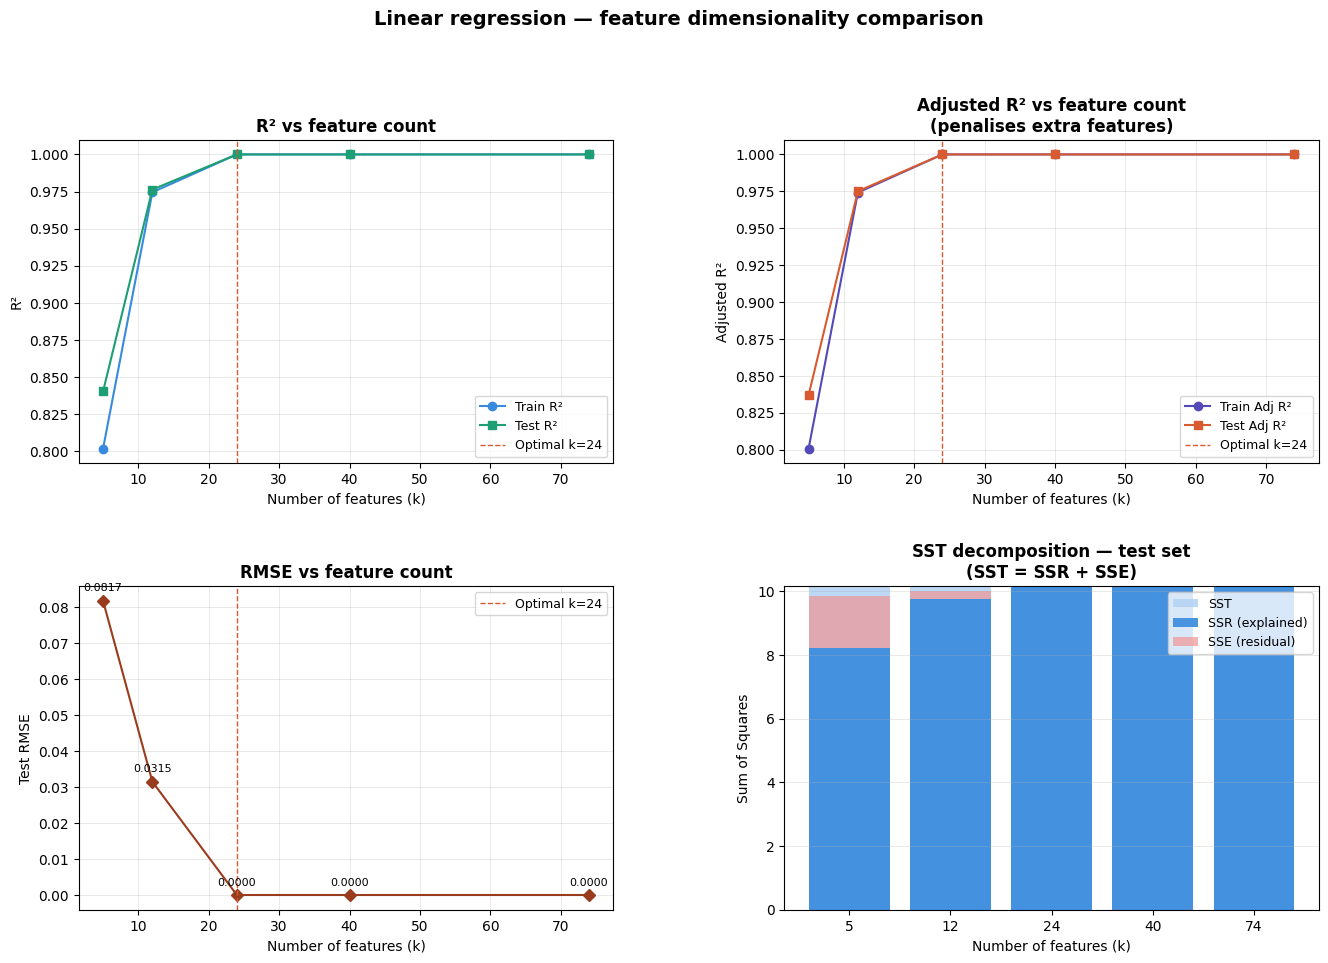


Optimal feature count  : k = 24
Test R²                : 1.0000
Test Adjusted R²       : 1.0000
Test RMSE              : 0.0000


In [ ]:

# Cell 31 — Visualise subset size comparison
#           Four panels: R² | Adj R² | RMSE | SSR/SSE/SST


ks          = [r["k"]          for r in subset_records]
tr_r2       = [r["train_R2"]   for r in subset_records]
te_r2       = [r["test_R2"]    for r in subset_records]
tr_r2adj    = [r["train_R2adj"]for r in subset_records]
te_r2adj    = [r["test_R2adj"] for r in subset_records]
te_rmse     = [r["test_RMSE"]  for r in subset_records]
sst_vals    = [r["SST_te"]     for r in subset_records]
ssr_vals    = [r["SSR_te"]     for r in subset_records]
sse_vals    = [r["SSE_te"]     for r in subset_records]

best_idx    = int(np.argmax(te_r2adj))
best_k      = ks[best_idx]

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.38, wspace=0.32)

# --- R² ---
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(ks, tr_r2,  marker="o", color="#378ADD", linewidth=1.5, label="Train R²")
ax1.plot(ks, te_r2,  marker="s", color="#1D9E75", linewidth=1.5, label="Test R²")
ax1.axvline(best_k, color="#D85A30", linestyle="--", linewidth=1,
            label=f"Optimal k={best_k}")
ax1.set_xlabel("Number of features (k)"); ax1.set_ylabel("R²")
ax1.set_title("R² vs feature count", fontweight="bold")
ax1.legend(fontsize=9); ax1.grid(linewidth=0.4, alpha=0.5)

# --- Adjusted R² ---
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(ks, tr_r2adj, marker="o", color="#534AB7", linewidth=1.5, label="Train Adj R²")
ax2.plot(ks, te_r2adj, marker="s", color="#D85A30", linewidth=1.5, label="Test Adj R²")
ax2.axvline(best_k, color="#D85A30", linestyle="--", linewidth=1,
            label=f"Optimal k={best_k}")
ax2.set_xlabel("Number of features (k)"); ax2.set_ylabel("Adjusted R²")
ax2.set_title("Adjusted R² vs feature count\n(penalises extra features)",
              fontweight="bold")
ax2.legend(fontsize=9); ax2.grid(linewidth=0.4, alpha=0.5)

# --- RMSE ---
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(ks, te_rmse, marker="D", color="#993C1D", linewidth=1.5)
ax3.axvline(best_k, color="#D85A30", linestyle="--", linewidth=1,
            label=f"Optimal k={best_k}")
for kv, rv in zip(ks, te_rmse):
    ax3.annotate(f"{rv:.4f}", (kv, rv),
                 textcoords="offset points", xytext=(0, 7),
                 ha="center", fontsize=8)
ax3.set_xlabel("Number of features (k)"); ax3.set_ylabel("Test RMSE")
ax3.set_title("RMSE vs feature count", fontweight="bold")
ax3.legend(fontsize=9); ax3.grid(linewidth=0.4, alpha=0.5)

# --- SSR / SSE / SST stacked ---
ax4 = fig.add_subplot(gs[1, 1])
x_pos = np.arange(len(ks))
ax4.bar(x_pos, sst_vals, label="SST", color="#B5D4F4", alpha=0.9)
ax4.bar(x_pos, ssr_vals, label="SSR (explained)", color="#378ADD", alpha=0.9)
ax4.bar(x_pos, sse_vals, bottom=ssr_vals, label="SSE (residual)",
        color="#F09595", alpha=0.7)
ax4.set_xticks(x_pos); ax4.set_xticklabels([str(k) for k in ks])
ax4.set_xlabel("Number of features (k)"); ax4.set_ylabel("Sum of Squares")
ax4.set_title("SST decomposition — test set\n(SST = SSR + SSE)",
              fontweight="bold")
ax4.legend(fontsize=9); ax4.grid(axis="y", linewidth=0.4, alpha=0.5)

fig.suptitle("Linear regression — feature dimensionality comparison",
             fontsize=14, fontweight="bold", y=1.01)
plt.savefig("dimensionality_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nOptimal feature count  : k = {best_k}")
print(f"Test R²                : {te_r2[best_idx]:.4f}")
print(f"Test Adjusted R²       : {te_r2adj[best_idx]:.4f}")
print(f"Test RMSE              : {te_rmse[best_idx]:.4f}")

we did not used the optimal feature count visualised on graphs  as it produced biased results among the data,being overfitting on the desicion tree making the activity score extremely dependent on desicion tree. Instead we choose 10 values for the interpretation shake of the model and to minimise bias. We choose an imperfect model to produce more accurate results.

In [ ]:

# Cell  32 — Use top 10 decision tree features

from sklearn.model_selection import train_test_split # Ensure train_test_split is imported here
from sklearn.linear_model import LinearRegression # Ensure LinearRegression is imported

# Re-define X_tr_raw, X_te_raw, y_tr, y_te in this cell to ensure they exist.
# This assumes X_regression_features and y_score are globally available from earlier cells (2 & 3 in this section).
if 'X_regression_features' not in globals() or 'y_score' not in globals():
    raise RuntimeError("Missing X_regression_features or y_score. Please ensure Cells 2 (xd655EgS7VbT) and 3 (q1zhLWjr7VbU) in 'Part 3b' are executed.")

X_tr_raw, X_te_raw, y_tr, y_te = train_test_split(
    X_regression_features, y_score,
    test_size=0.20, random_state=42
)

chosen_k  = 10
top_k_idx = sorted_imp_idx[:chosen_k]

X_tr_c = X_tr_raw[:, top_k_idx]
X_te_c = X_te_raw[:, top_k_idx]

lm_chosen = LinearRegression()
lm_chosen.fit(X_tr_c, y_tr)

final_feature_names = sel_features[top_k_idx]

print(f"Using top {chosen_k} features from decision tree importance ranking:")
print()
for rank, (fname, imp) in enumerate(
        zip(final_feature_names, importances[top_k_idx]), 1):
    print(f"  {rank:2d}. {fname:12s}  DT importance = {imp:.6f}")

Using top 10 features from decision tree importance ranking:

   1. Target98      DT importance = 0.120091
   2. Target175     DT importance = 0.103581
   3. Target194     DT importance = 0.099319
   4. Target208     DT importance = 0.081600
   5. Target86      DT importance = 0.081095
   6. Target191     DT importance = 0.071412
   7. Target74      DT importance = 0.068089
   8. Target42      DT importance = 0.059809
   9. Target354     DT importance = 0.052273
  10. Target176     DT importance = 0.042297


In [ ]:
# Cell 33 — Final model: full statistics printout

y_pred_tr_fin = lm_chosen.predict(X_tr_c)
y_pred_te_fin = lm_chosen.predict(X_te_c)

s_tr_fin = regression_stats(y_tr, y_pred_tr_fin, chosen_k)
s_te_fin = regression_stats(y_te, y_pred_te_fin, chosen_k)

print_stats(f"TRAIN SET — k={chosen_k} features", s_tr_fin)
print_stats(f"TEST  SET — k={chosen_k} features", s_te_fin)

# Cross-validated R² (5-fold)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(
    LinearRegression(),
    np.vstack([X_tr_c, X_te_c]),
    np.concatenate([y_tr, y_te]),
    cv=cv, scoring="r2"
)
print(f"\n  5-fold CV R²  : {cv_r2.mean():.4f} ± {cv_r2.std():.4f}")
print(f"  Per fold      : {[round(s,4) for s in cv_r2]}")


  TRAIN SET — k=10 features
  n (samples)      : 970
  p (features)     : 10
  SST              : 35.255156
  SSR (explained)  : 33.623534  (95.37%)
  SSE (residual)   : 1.631622  (4.63%)
  R²               : 0.953720
  Adjusted R²      : 0.953237
  RMSE             : 0.041013
  MAE              : 0.031189

  TEST  SET — k=10 features
  n (samples)      : 243
  p (features)     : 10
  SST              : 10.156846
  SSR (explained)  : 9.702134  (95.52%)
  SSE (residual)   : 0.403235  (3.97%)
  R²               : 0.960299
  Adjusted R²      : 0.958588
  RMSE             : 0.040736
  MAE              : 0.032341

  5-fold CV R²  : 0.9539 ± 0.0042
  Per fold      : [np.float64(0.9539), np.float64(0.9473), np.float64(0.9554), np.float64(0.9601), np.float64(0.9526)]


In [ ]:
# Cell 34 — Coefficient analysis
#           Ranked list of biological targets by contribution
final_feature_names = sel_features[top_k_idx]
coefficients        = lm_chosen.coef_
intercept           = lm_chosen.intercept_

coef_df = pd.DataFrame({
    "Target"     : final_feature_names,
    "Coefficient": coefficients,
    "Abs_Coef"   : np.abs(coefficients),
    "Direction"  : ["Positive" if c > 0 else "Negative" for c in coefficients],
}).sort_values("Abs_Coef", ascending=False).reset_index(drop=True)

print(f"Intercept : {intercept:.6f}\n")
print(f"Top {chosen_k} targets by coefficient magnitude (from {len(final_feature_names)} features used in the model):")
print(coef_df.head(chosen_k).to_string(index=False))

coef_df.to_csv("coefficient_ranking.csv", index=False)
print("\nFull ranking saved to coefficient_ranking.csv")


Intercept : 0.040684

Top 10 targets by coefficient magnitude (from 10 features used in the model):
   Target  Coefficient  Abs_Coef Direction
 Target98     0.189845  0.189845  Positive
Target194     0.156553  0.156553  Positive
Target191     0.148917  0.148917  Positive
Target175     0.144857  0.144857  Positive
Target208     0.115547  0.115547  Positive
 Target86     0.101323  0.101323  Positive
 Target74     0.094800  0.094800  Positive
Target354     0.084977  0.084977  Positive
Target176     0.073709  0.073709  Positive
 Target42     0.070639  0.070639  Positive

Full ranking saved to coefficient_ranking.csv


In [ ]:

# Cell 35 — Display sorted coefficients

# Dependencies: importances , sel_features , chosen_k
# Note: final_feature_names and lm_chosen are expected to be defined by previous cells (e.g., hIPsvLFG7VbW).

coef_df_sorted = pd.DataFrame({
    "Feature": final_feature_names,
    "Coefficient": lm_chosen.coef_
}).sort_values(by="Coefficient", ascending=False).reset_index(drop=True)

display(coef_df_sorted)

,Feature,Coefficient
0,Target98,0.189845
1,Target194,0.156553
2,Target191,0.148917
3,Target175,0.144857
4,Target208,0.115547
5,Target86,0.101323
6,Target74,0.094800
7,Target354,0.084977
8,Target176,0.073709
9,Target42,0.070639


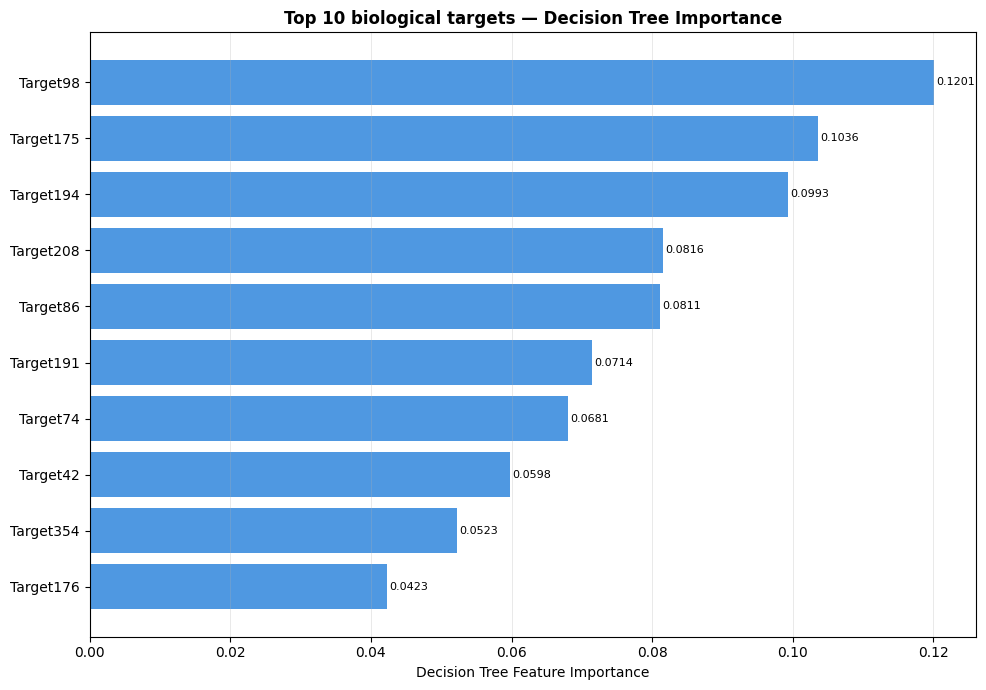

In [ ]:

# Cell 36 — Decision Tree Feature Importance visualisation


# Get feature importances for the chosen_k features (used in linear regression)
# These are derived from the original Decision Tree model.
chosen_k_importances = importances[top_k_idx]

dt_imp_df = pd.DataFrame({
    "Target": final_feature_names,
    "Importance": chosen_k_importances,
}).sort_values("Importance", ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(dt_imp_df["Target"], dt_imp_df["Importance"],
               color="#378ADD", alpha=0.88)

for bar, val in zip(bars, dt_imp_df["Importance"]):
    ax.text(val + 0.0003, bar.get_y() + bar.get_height()/2,
            f"{val:.4f}", va="center", ha="left", fontsize=8)

ax.set_xlabel("Decision Tree Feature Importance")
ax.set_title(f"Top {chosen_k} biological targets — Decision Tree Importance",
             fontweight="bold")
ax.grid(axis="x", linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("decision_tree_importance_k_features.png", dpi=150, bbox_inches="tight")
plt.show()

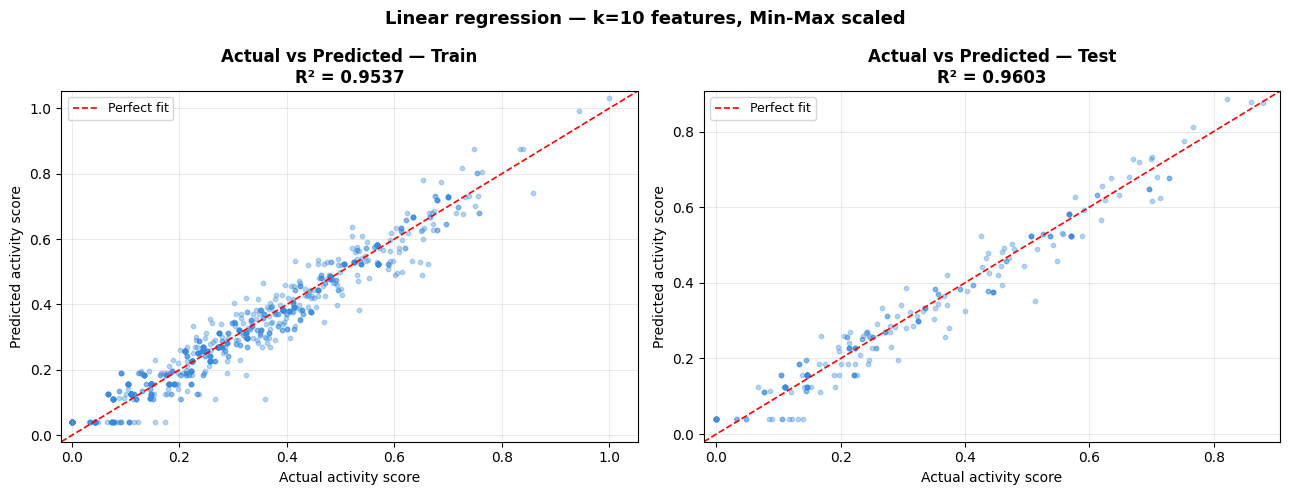

In [ ]:

# Cell 37 — Actual vs Predicted scatter

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, y_true, y_pred, split_label in [
    (axes[0], y_tr, y_pred_tr_fin, "Train"),
    (axes[1], y_te, y_pred_te_fin, "Test"),
]:
    r2_val = r2_score(y_true, y_pred)
    ax.scatter(y_true, y_pred, alpha=0.35, s=10, color="#378ADD")
    lims = [min(y_true.min(), y_pred.min()) - 0.02,
            max(y_true.max(), y_pred.max()) + 0.02]
    ax.plot(lims, lims, "r--", linewidth=1.2, label="Perfect fit")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("Actual activity score")
    ax.set_ylabel("Predicted activity score")
    ax.set_title(f"Actual vs Predicted — {split_label}\nR² = {r2_val:.4f}",
                 fontweight="bold")
    ax.legend(fontsize=9)
    ax.grid(linewidth=0.4, alpha=0.5)

plt.suptitle(f"Linear regression — k={chosen_k} features, Min-Max scaled",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()


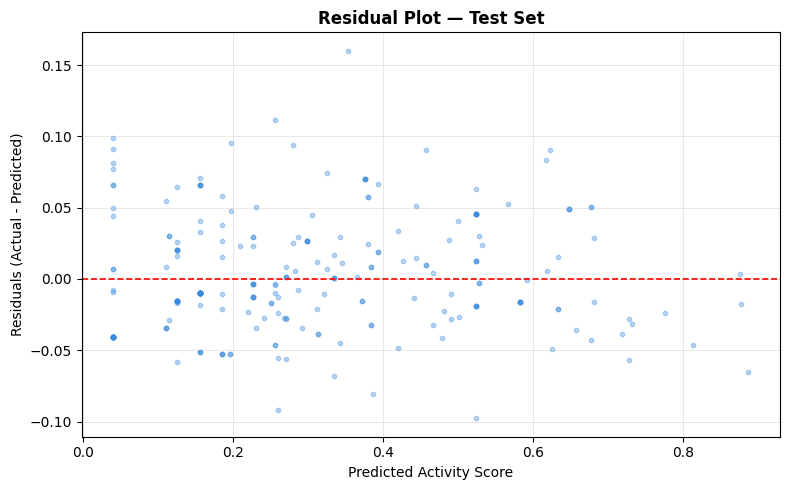

In [ ]:
# Cell 38 — Residuals Diagnosis Plot
import matplotlib.pyplot as plt

residuals = y_te - y_pred_te_fin

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(y_pred_te_fin, residuals, alpha=0.35, s=10, color="#378ADD")
ax.axhline(0, color='r', linestyle='--', linewidth=1.2)
ax.set_title("Residual Plot — Test Set", fontweight="bold")
ax.set_xlabel("Predicted Activity Score")
ax.set_ylabel("Residuals (Actual - Predicted)")
ax.grid(linewidth=0.4, alpha=0.5)
plt.tight_layout()
plt.savefig("residual_plot.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:

# Cell 39 — Summary table across all subset sizes

summary = pd.DataFrame({
    "k (features)"  : [r["k"]           for r in subset_records],
    "Train R²"      : [round(r["train_R2"],    4) for r in subset_records],
    "Train Adj R²"  : [round(r["train_R2adj"], 4) for r in subset_records],
    "Test R²"       : [round(r["test_R2"],     4) for r in subset_records],
    "Test Adj R²"   : [round(r["test_R2adj"],  4) for r in subset_records],
    "Test RMSE"     : [round(r["test_RMSE"],   4) for r in subset_records],
    "SST (test)"    : [round(r["SST_te"],      4) for r in subset_records],
    "SSR (test)"    : [round(r["SSR_te"],      4) for r in subset_records],
    "SSE (test)"    : [round(r["SSE_te"],      4) for r in subset_records],
})
summary["Overfit gap"] = (summary["Train R²"] - summary["Test R²"]).round(4)
summary["Chosen"]      = summary["k (features)"] == chosen_k

print(summary.to_string(index=False))
summary.to_csv("regression_summary.csv", index=False)
print("\nSaved to regression_summary.csv")

 k (features)  Train R²  Train Adj R²  Test R²  Test Adj R²  Test RMSE  SST (test)  SSR (test)  SSE (test)  Overfit gap  Chosen
            5    0.8017        0.8007   0.8403       0.8369     0.0817     10.1568      8.2297      1.6225      -0.0386   False
           12    0.9745        0.9742   0.9763       0.9751     0.0315     10.1568      9.7687      0.2408      -0.0018   False
           24    1.0000        1.0000   1.0000       1.0000     0.0000     10.1568     10.1568      0.0000       0.0000   False
           40    1.0000        1.0000   1.0000       1.0000     0.0000     10.1568     10.1568      0.0000       0.0000   False
           74    1.0000        1.0000   1.0000       1.0000     0.0000     10.1568     10.1568      0.0000       0.0000   False

Saved to regression_summary.csv


it was meaningful to say we opted for less than optimal to an interpretable number, of the desicion tree features in order to reduce overfitting  & potential bias and produce interpretable results a=96% accuracy was achieved ,indicating a high interpretable model but in further analysis it should be examined better for bias detection

## Part 4 — MapReduce Parallel Cluster Scoring

In [ ]:

# Cell 40 — Imports

!pip install joblib --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
from joblib import Parallel, delayed
from sklearn.cluster import KMeans
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
from multiprocessing import cpu_count
import warnings, time
warnings.filterwarnings('ignore')

print(f"Libraries loaded successfully.")
print(f"Available CPU cores : {cpu_count()}")
print(f"Recommended workers : {min(4, cpu_count())}")

Libraries loaded successfully.
Available CPU cores : 2
Recommended workers : 2


In [ ]:
# Cell 41 — Guided user input with validation + live preview


def ask(prompt, default, cast=str, choices=None, lo=None, hi=None):
    """
    Prompt helper — shows default, validates range/choices,
    returns cast value. Keeps asking until input is valid.
    """
    while True:
        raw = input(f"  {prompt} [default={default}]: ").strip()
        val = raw if raw else str(default)
        try:
            val = cast(val)
        except ValueError:
            print(f"    ✗ must be {cast.__name__}. Try again.")
            continue
        if choices and val not in choices:
            print(f"    ✗ must be one of {choices}. Try again.")
            continue
        if lo is not None and val < lo:
            print(f"    ✗ minimum is {lo}. Try again.")
            continue
        if hi is not None and val > hi:
            print(f"    ✗ maximum is {hi}. Try again.")
            continue
        return val

print("=" * 62)
print("  MAPREDUCE PIPELINE — INTERACTIVE CONFIGURATION")
print("=" * 62)
print()

# --- Workers ---
print("[ 1 / 5 ]  Parallel workers")
print(f"           Your machine has {cpu_count()} cores.")
print("           More workers = faster map phase.")
N_WORKERS = ask("Number of workers", min(4, cpu_count()),
                int, lo=1, hi=cpu_count())
print()

# --- Clusters ---
print("[ 2 / 5 ]  K-Means clusters")
print("           Controls how finely ingredients are grouped.")
print("           Typical range: 3 – 10.")
N_CLUSTERS = ask("Number of clusters", 5, int, lo=2, hi=20)
print()

# --- Scoring ---
print("[ 3 / 5 ]  Activity score method")
print("           1 = weighted  (tree importance × target activation)")
print("           2 = simple    (equal-weight sum of active targets)")
print("           3 = top10     (sum of top-10 DT features only)")
score_choice = ask("Method", "1", str, choices=["1","2","3"])
SCORE_METHOD = {"1":"weighted","2":"simple","3":"top10"}[score_choice]
print()

# --- Ranking ---
print("[ 4 / 5 ]  Cluster ranking criteria")
print("           1 = mean_score       (highest pharmacological activity)")
print("           2 = dual_action_pct  (most dual-action ingredients)")
print("           3 = variance         (most heterogeneous cluster)")
rank_choice = ask("Rank by", "1", str, choices=["1","2","3"])
RANK_BY     = {"1":"mean_score","2":"dual_action_pct","3":"variance"}[rank_choice]
print()

# --- Seed ---
print("[ 5 / 5 ]  Reproducibility")
SEED = ask("Random seed", 42, int, lo=0, hi=99999)
print()

# --- Confirmed summary ---
print("=" * 62)
print("  Configuration confirmed — starting pipeline")
print("=" * 62)
print(f"  Workers      : {N_WORKERS}")
print(f"  Clusters     : {N_CLUSTERS}")
print(f"  Score method : {SCORE_METHOD}")
print(f"  Rank by      : {RANK_BY}")
print(f"  Seed         : {SEED}")
print("=" * 62)

PALETTE = ["#378ADD","#1D9E75","#534AB7","#D85A30",
           "#BA7517","#993C1D","#0F6E56","#3C3489",
           "#712B13","#3B6D11"]

  MAPREDUCE PIPELINE — INTERACTIVE CONFIGURATION

[ 1 / 5 ]  Parallel workers
           Your machine has 2 cores.
           More workers = faster map phase.
  Number of workers [default=2]: 2

[ 2 / 5 ]  K-Means clusters
           Controls how finely ingredients are grouped.
           Typical range: 3 – 10.
  Number of clusters [default=5]: 5

[ 3 / 5 ]  Activity score method
           1 = weighted  (tree importance × target activation)
           2 = simple    (equal-weight sum of active targets)
           3 = top10     (sum of top-10 DT features only)
  Method [default=1]: 1

[ 4 / 5 ]  Cluster ranking criteria
           1 = mean_score       (highest pharmacological activity)
           2 = dual_action_pct  (most dual-action ingredients)
           3 = variance         (most heterogeneous cluster)
  Rank by [default=1]: 2

[ 5 / 5 ]  Reproducibility
  Random seed [default=42]: 42

  Configuration confirmed — starting pipeline
  Workers      : 2
  Clusters     : 5
  Score metho


*   **Parallel workers 2:** Selected to match the available CPU cores, optimizing for efficiency.
*   **K-Means clusters 5:** Chosen based on the clustering k-means diagram and validated by the elbow method
*   **Activity score method weighted :** This method uses decision tree importance multiplied by target activation
*   **Cluster ranking criteria dual action :** Prioritized to identify clusters with the highest proportion of dual-action ingredients, finding pharmacological efficiency the dual -action category provides
*   **Random seed 42:** Set for reproducibility

In [ ]:
# Cell 42 — Prepare master feature matrix


X_full      = df[target_cols].values.astype(float)
X_sel_mr    = selector.transform(X_full)
imp_sel     = final_model['model'].feature_importances_

sorted_imp_idx_mr = np.argsort(imp_sel)[::-1]
top10_idx         = sorted_imp_idx_mr[:10]

# X_regression_features_mr is already 0/1 binary, so explicit scaling is not needed as it does not change the values.
X_regression_features_mr = X_sel_mr

y_anti          = df["label_antipyretic"].values
y_cough         = df["label_cough"].values
y_dual          = df["label_dual_action"].values
class_label_arr = df["multiclass_label"].values
ingredients     = df["Ingredient"].values
sel_feat_names  = np.array(target_cols)[selector.get_support()]

print(f"Feature matrix (already 0/1 binary) : {X_regression_features_mr.shape}")
print(f"Ingredients      : {len(ingredients)}")
print(f"Dual-action      : {y_dual.sum()}")
print(f"Top-10 features  : {list(sel_feat_names[top10_idx])}")

Feature matrix (already 0/1 binary) : (1213, 74)
Ingredients      : 1213
Dual-action      : 56
Top-10 features  : [np.str_('Target98'), np.str_('Target175'), np.str_('Target194'), np.str_('Target208'), np.str_('Target86'), np.str_('Target191'), np.str_('Target74'), np.str_('Target42'), np.str_('Target354'), np.str_('Target176')]


Fitting K-Means  (k=5)...
Done in 0.07s



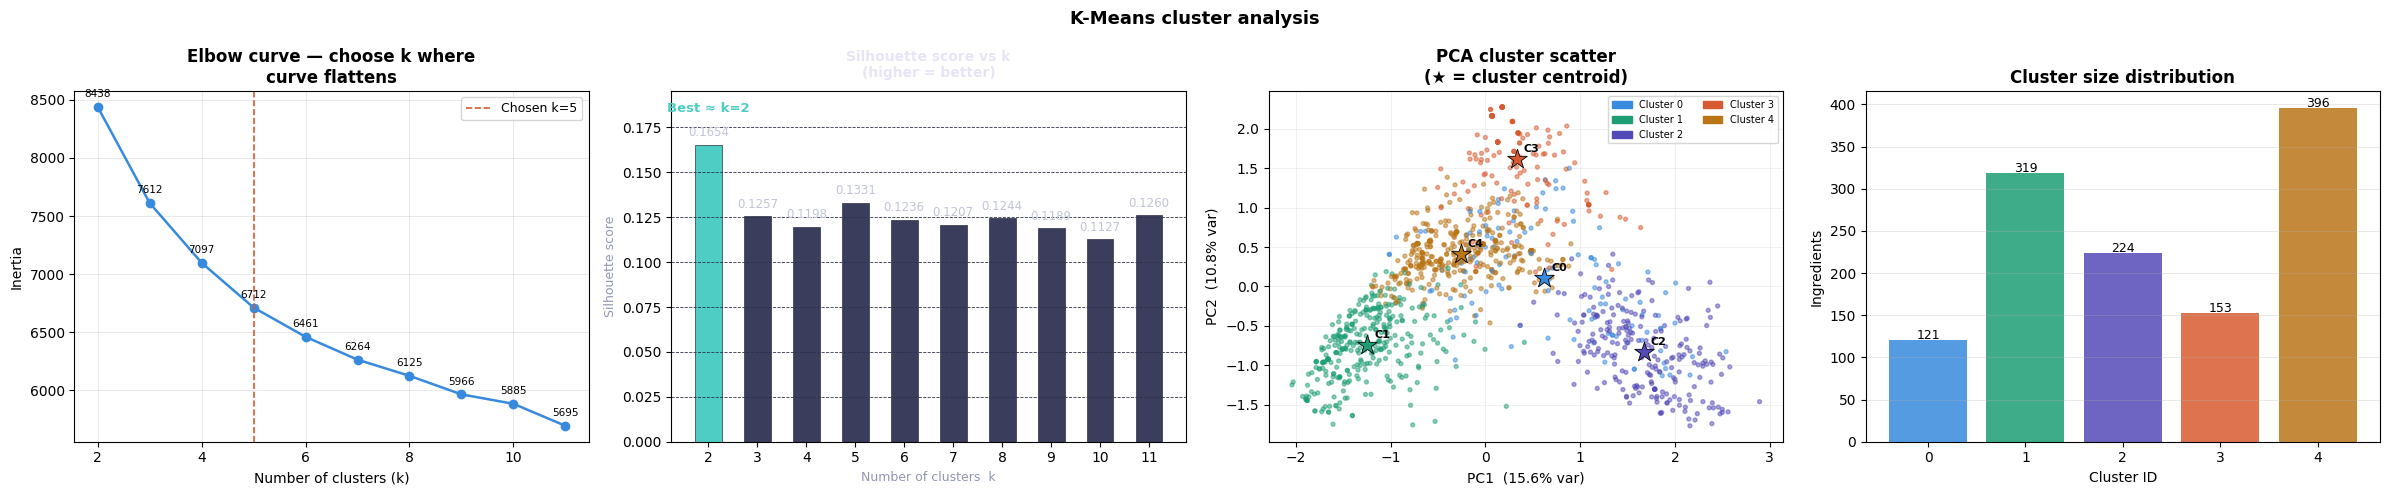

Cluster distribution:
  Cluster 0:  121  (10.0%)  ███
  Cluster 1:  319  (26.3%)  ██████████
  Cluster 2:  224  (18.5%)  ███████
  Cluster 3:  153  (12.6%)  █████
  Cluster 4:  396  (32.6%)  █████████████

Silhouette Score for chosen k=5: 0.1331


In [ ]:

# Cell 43 — Fit K-Means + visualise cluster quality


print(f"Fitting K-Means  (k={N_CLUSTERS})...")
t0 = time.time()
kmeans = KMeans(n_clusters=N_CLUSTERS, init="k-means++",
                max_iter=300, random_state=SEED, n_init=10)
cluster_labels = kmeans.fit_predict(X_regression_features_mr)
km_time = time.time() - t0
print(f"Done in {km_time:.2f}s\n")

# Inertia and Silhouette sweep for elbow and silhouette plots
k_range   = range(2, min(12, len(ingredients)//50 + 3))
inertias  = []
sil_scores = []

for k in k_range:
    km_tmp = KMeans(n_clusters=k, init="k-means++", max_iter=100,
                    random_state=SEED, n_init=5)
    km_tmp.fit(X_regression_features_mr)
    inertias.append(km_tmp.inertia_)
    # Calculate Silhouette Score
    # Ensure sample_size is appropriate, especially for smaller datasets
    sc = silhouette_score(X_regression_features_mr, km_tmp.labels_, sample_size=min(500, len(X_regression_features_mr)), random_state=SEED)
    sil_scores.append(sc)

# PCA for 2-D cluster scatter
pca    = PCA(n_components=2, random_state=SEED)
X_pca  = pca.fit_transform(X_regression_features_mr)
var_ex = pca.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 4, figsize=(24, 5)) # Expanded to 4 subplots
fig.suptitle("K-Means cluster analysis", fontsize=13, fontweight="bold")

# Elbow curve
ax = axes[0]
ax.plot(list(k_range), inertias, marker="o", color="#378ADD", linewidth=1.8)
ax.axvline(N_CLUSTERS, color="#D85A30", linestyle="--",
           linewidth=1.2, label=f"Chosen k={N_CLUSTERS}")
for k, ine in zip(k_range, inertias):
    ax.annotate(f"{ine:.0f}", (k, ine),
                textcoords="offset points", xytext=(0, 7),
                ha="center", fontsize=7.5)
ax.set_xlabel("Number of clusters (k)")
ax.set_ylabel("Inertia")
ax.set_title("Elbow curve — choose k where\ncurve flattens",
             fontweight="bold")
ax.legend(fontsize=9); ax.grid(linewidth=0.4, alpha=0.5)

# Silhouette Score plot
ax_sil = axes[1]
bar_colors_sil = ["#3a3e5c"] * len(k_range)
if sil_scores: # Check if sil_scores is not empty
    best_sil_k_idx = sil_scores.index(max(sil_scores))
    bar_colors_sil[best_sil_k_idx] = "#4ecdc4"
bars_sil = ax_sil.bar(list(k_range), sil_scores, color=bar_colors_sil,
                   edgecolor="#2e3148", linewidth=0.5, width=0.55)

for bar, score in zip(bars_sil, sil_scores):
    ax_sil.text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 0.003,
                 f"{score:.4f}",
                 ha="center", va="bottom", fontsize=8.5, color="#c0c4d6")

ax_sil.set_title("Silhouette score vs k\n(higher = better)",
                  color="#e8e4f6", fontsize=10, pad=10, fontweight="bold")
ax_sil.set_xlabel("Number of clusters  k", color="#9196b3", fontsize=9)
ax_sil.set_ylabel("Silhouette score", color="#9196b3", fontsize=9)
ax_sil.set_xticks(list(k_range))
ax_sil.set_ylim(0, max(sil_scores) * 1.18 if sil_scores else 1.0) # Ensure ylim is valid
ax_sil.grid(axis="y", color="#2e3148", linewidth=0.6, linestyle="--")

if sil_scores: # Only add text if there are scores
    best_k_sil_plot = list(k_range)[best_sil_k_idx]
    ax_sil.text(best_k_sil_plot, max(sil_scores) + 0.018,
             f"Best ≈ k={best_k_sil_plot}", color="#4ecdc4",
             ha="center", fontsize=9.5, fontweight="bold")


# PCA scatter (now axes[2])
ax2    = axes[2]
c_list = [PALETTE[c % len(PALETTE)] for c in cluster_labels]
ax2.scatter(X_pca[:, 0], X_pca[:, 1],
            c=c_list, s=8, alpha=0.5)
centers_pca = pca.transform(kmeans.cluster_centers_)
for i, cp in enumerate(centers_pca):
    ax2.scatter(*cp, marker="*", s=220,
                color=PALETTE[i % len(PALETTE)],
                edgecolors="black", linewidth=0.6, zorder=5)
    ax2.annotate(f"C{i}", cp,
                 textcoords="offset points", xytext=(5, 5),
                 fontsize=8, fontweight="bold")
ax2.set_xlabel(f"PC1  ({var_ex[0]:.1f}% var)")
ax2.set_ylabel(f"PC2  ({var_ex[1]:.1f}% var)")
ax2.set_title("PCA cluster scatter\n(★ = cluster centroid)",
              fontweight="bold")
patches = [mpatches.Patch(color=PALETTE[i % len(PALETTE)],
                           label=f"Cluster {i}")
           for i in range(N_CLUSTERS)]
ax2.legend(handles=patches, fontsize=7,
           loc="upper right", ncol=2)
ax2.grid(linewidth=0.4, alpha=0.3)

# Cluster size bar (now axes[3])
ax3 = axes[3]
uniq, cnts = np.unique(cluster_labels, return_counts=True)
bars = ax3.bar(uniq, cnts,
               color=[PALETTE[i % len(PALETTE)] for i in uniq],
               alpha=0.85)
for bar, v in zip(bars, cnts):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1, str(v),
             ha="center", fontsize=9)
ax3.set_xlabel("Cluster ID"); ax3.set_ylabel("Ingredients")
ax3.set_title("Cluster size distribution", fontweight="bold")
ax3.grid(axis="y", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig("cluster_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Cluster distribution:")
for c, n in zip(uniq, cnts):
    bar = "█" * int(n/len(ingredients)*40)
    print(f"  Cluster {c}: {n:4d}  ({n/len(ingredients)*100:.1f}%)  {bar}")

# Print Silhouette Score for the chosen N_CLUSTERS
if N_CLUSTERS in k_range:
    chosen_k_index = list(k_range).index(N_CLUSTERS)
    print(f"\nSilhouette Score for chosen k={N_CLUSTERS}: {sil_scores[chosen_k_index]:.4f}")
else:
    print(f"\nSilhouette Score for chosen k={N_CLUSTERS}: Not calculated in sweep (k_range was {list(k_range)}) ")

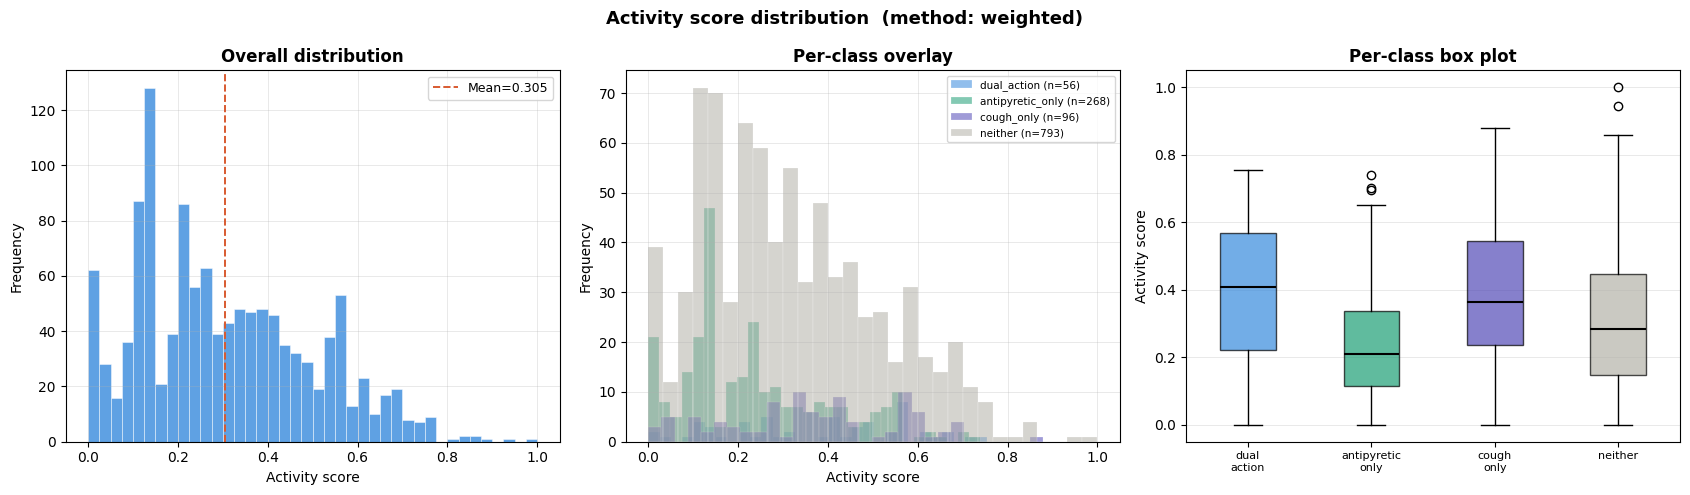

Activity score summary:
  Min  : 0.0000
  Max  : 1.0000
  Mean : 0.3045
  Std  : 0.1935


In [ ]:

# Cell 44 — Activity score computation + distribution


if SCORE_METHOD == "weighted":
    raw_scores = X_regression_features_mr @ imp_sel
elif SCORE_METHOD == "simple":
    raw_scores = X_regression_features_mr.sum(axis=1)
elif SCORE_METHOD == "top10":
    raw_scores = X_regression_features_mr[:, top10_idx].sum(axis=1)

activity_scores = (raw_scores - raw_scores.min()) / \
                  (raw_scores.max() - raw_scores.min() + 1e-10)

# Per-class score distribution
class_order  = ["dual_action","antipyretic_only","cough_only","neither"]
class_colors = ["#378ADD","#1D9E75","#534AB7","#B4B2A9"]
mask_dict    = {
    "dual_action"      : (y_dual == 1),
    "antipyretic_only" : (y_anti == 1) & (y_cough == 0),
    "cough_only"       : (y_cough == 1) & (y_anti == 0),
    "neither"          : (y_anti == 0) & (y_cough == 0),
}

fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle(f"Activity score distribution  (method: {SCORE_METHOD})",
             fontsize=13, fontweight="bold")

# Overall histogram
ax = axes[0]
ax.hist(activity_scores, bins=40, color="#378ADD",
        alpha=0.8, edgecolor="white", linewidth=0.4)
ax.axvline(activity_scores.mean(), color="#D85A30",
           linestyle="--", linewidth=1.4,
           label=f"Mean={activity_scores.mean():.3f}")
ax.set_xlabel("Activity score"); ax.set_ylabel("Frequency")
ax.set_title("Overall distribution", fontweight="bold")
ax.legend(fontsize=9); ax.grid(linewidth=0.4, alpha=0.5)

# Per-class overlay
ax2 = axes[1]
for cls, color in zip(class_order, class_colors):
    mask = mask_dict[cls]
    ax2.hist(activity_scores[mask], bins=30, alpha=0.55,
             color=color, label=f"{cls} (n={mask.sum()})",
             edgecolor="white", linewidth=0.3)
ax2.set_xlabel("Activity score"); ax2.set_ylabel("Frequency")
ax2.set_title("Per-class overlay", fontweight="bold")
ax2.legend(fontsize=7.5); ax2.grid(linewidth=0.4, alpha=0.5)

# Per-class box plot
ax3 = axes[2]
bp_data   = [activity_scores[mask_dict[c]] for c in class_order]
bp        = ax3.boxplot(bp_data, patch_artist=True,
                         medianprops={"color":"black","linewidth":1.5})
for patch, color in zip(bp["boxes"], class_colors):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax3.set_xticklabels([c.replace("_","\n") for c in class_order],
                     fontsize=8)
ax3.set_ylabel("Activity score")
ax3.set_title("Per-class box plot", fontweight="bold")
ax3.grid(axis="y", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig("activity_score_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Activity score summary:")
print(f"  Min  : {activity_scores.min():.4f}")
print(f"  Max  : {activity_scores.max():.4f}")
print(f"  Mean : {activity_scores.mean():.4f}")
print(f"  Std  : {activity_scores.std():.4f}")

activity score was shown on how it was generally distributed on the model.Especially, in dual action based on box plot the activity score had a largely large scope, compared to others , making it pharmacologically efficient

Balanced shard report:
 worker_id  total  dual_action  antipyretic  cough_only  neither  cluster_0  cluster_1  cluster_2  cluster_3  cluster_4
         0    611           29          135          49      398         61        161        112         78        199
         1    602           27          133          47      395         60        158        112         75        197

Max shard deviation : 9 ingredient(s)


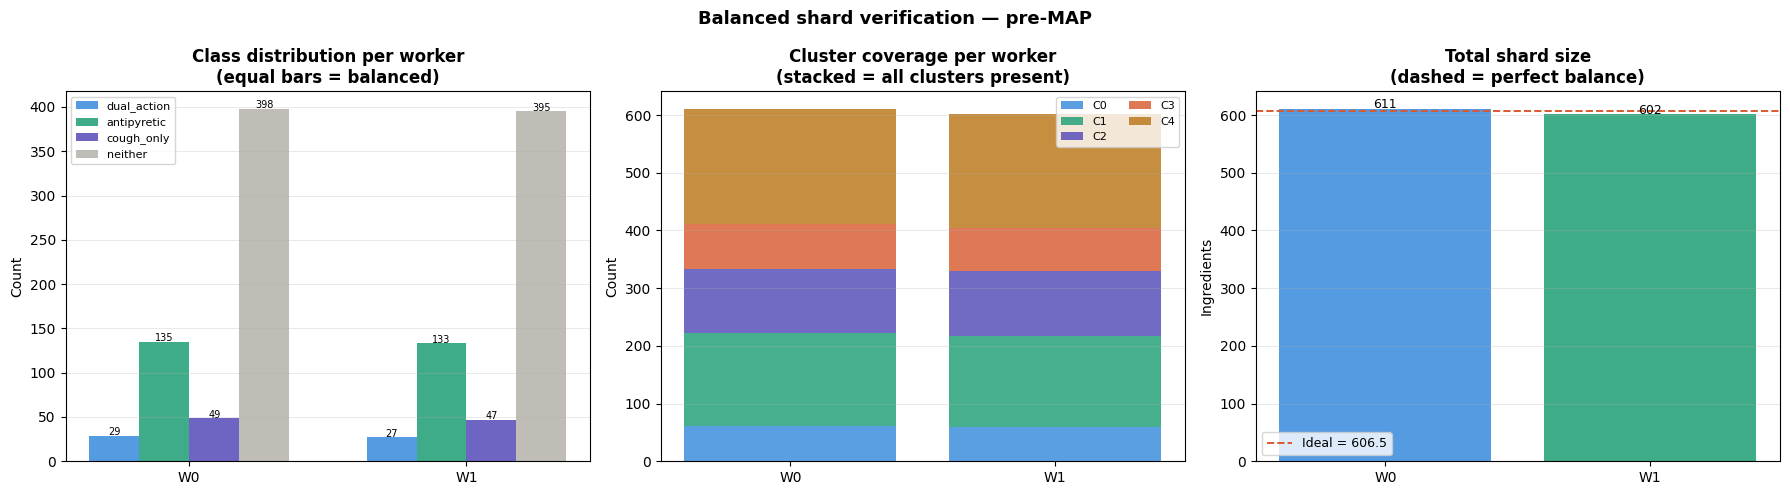

In [ ]:
# Cell 45 — Balanced shard builder + verification

def build_balanced_shards(n_workers, cluster_labels,
                           class_labels, random_state=42):
    rng       = np.random.default_rng(random_state)
    strat_key = np.array([f"c{cl}_k{ck}"
                           for cl, ck in zip(class_labels, cluster_labels)])
    shards    = [[] for _ in range(n_workers)]
    for stratum in np.unique(strat_key):
        idx = rng.permutation(np.where(strat_key == stratum)[0])
        for pos, gidx in enumerate(idx):
            shards[pos % n_workers].append(int(gidx))
    shards = [np.array(sorted(s)) for s in shards]
    rows   = []
    for wid, shard in enumerate(shards):
        cl_c = pd.Series(class_labels[shard]).value_counts().to_dict()
        ck_c = pd.Series(cluster_labels[shard]).value_counts().to_dict()
        rows.append({
            "worker_id"   : wid,
            "total"       : len(shard),
            "dual_action" : cl_c.get("dual_action",      0),
            "antipyretic" : cl_c.get("antipyretic_only", 0),
            "cough_only"  : cl_c.get("cough_only",       0),
            "neither"     : cl_c.get("neither",          0),
            **{f"cluster_{k}": ck_c.get(k, 0)
               for k in sorted(ck_c)},
        })
    return shards, pd.DataFrame(rows)


balanced_shards, shard_report = build_balanced_shards(
    N_WORKERS, cluster_labels, class_label_arr, SEED
)

print("Balanced shard report:")
print(shard_report.to_string(index=False))
sizes = shard_report["total"].values
print(f"\nMax shard deviation : {sizes.max()-sizes.min()} ingredient(s)")

# Visualise balance
n_w   = len(balanced_shards)
xw    = np.arange(n_w)
width = 0.18
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Balanced shard verification — pre-MAP",
             fontsize=13, fontweight="bold")

# Class counts per worker
ax     = axes[0]
offsets = np.linspace(-1.5*width, 1.5*width, 4)
for offset, col, color in zip(
        offsets,
        ["dual_action","antipyretic","cough_only","neither"],
        class_colors):
    vals = shard_report[col].values
    bars = ax.bar(xw + offset, vals, width,
                  label=col, color=color, alpha=0.85)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.3, str(v),
                ha="center", fontsize=7)
ax.set_xticks(xw)
ax.set_xticklabels([f"W{i}" for i in range(n_w)])
ax.set_ylabel("Count")
ax.set_title("Class distribution per worker\n"
             "(equal bars = balanced)", fontweight="bold")
ax.legend(fontsize=8); ax.grid(axis="y", linewidth=0.4, alpha=0.5)

# Cluster coverage per worker
ax2 = axes[1]
clust_cols = [c for c in shard_report.columns if c.startswith("cluster_")]
bottom2    = np.zeros(n_w)
for ci, (col, color) in enumerate(zip(clust_cols,
                                       [PALETTE[i % len(PALETTE)]
                                        for i in range(len(clust_cols))])):
    vals2 = shard_report[col].values
    ax2.bar(xw, vals2, bottom=bottom2, color=color,
            alpha=0.82, label=col.replace("cluster_","C"))
    bottom2 += vals2
ax2.set_xticks(xw)
ax2.set_xticklabels([f"W{i}" for i in range(n_w)])
ax2.set_ylabel("Count"); ax2.set_title("Cluster coverage per worker\n"
                                        "(stacked = all clusters present)",
                                        fontweight="bold")
ax2.legend(fontsize=8, ncol=2); ax2.grid(axis="y", linewidth=0.4, alpha=0.5)

# Shard size + ideal line
ax3   = axes[2]
ideal = len(ingredients) / n_w
bars3 = ax3.bar(xw, shard_report["total"].values,
                color=[PALETTE[i % len(PALETTE)] for i in range(n_w)],
                alpha=0.85)
ax3.axhline(ideal, color="#D85A30", linestyle="--",
            linewidth=1.4, label=f"Ideal = {ideal:.1f}")
for bar, v in zip(bars3, shard_report["total"].values):
    ax3.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.5, str(v),
             ha="center", fontsize=9)
ax3.set_xticks(xw)
ax3.set_xticklabels([f"W{i}" for i in range(n_w)])
ax3.set_ylabel("Ingredients")
ax3.set_title("Total shard size\n(dashed = perfect balance)",
              fontweight="bold")
ax3.legend(fontsize=9); ax3.grid(axis="y", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig("shard_balance.png", dpi=150, bbox_inches="tight")
plt.show()

workers had  almost equal distribution among clusters and classes in order to work without overhead and imbalance  to produce meaningful results

In [ ]:

# Cell 46— MAP worker function


def map_worker(worker_id, indices,
               X_shard, scores_shard, cluster_shard,
               y_anti_shard, y_cough_shard, y_dual_shard,
               ingredient_shard, score_method,
               importances, top10_idx):
    results = []
    for i in range(len(indices)):
        x = X_shard[i]
        if score_method == "weighted":
            score = float(np.dot(x, importances))
        elif score_method == "simple":
            score = float(x.sum())
        else:
            score = float(x[top10_idx].sum())
        results.append({
            "worker_id"      : worker_id,
            "global_idx"     : int(indices[i]),
            "ingredient"     : ingredient_shard[i],
            "cluster_id"     : int(cluster_shard[i]),
            "activity_score" : score,
            "is_antipyretic" : int(y_anti_shard[i]),
            "is_cough"       : int(y_cough_shard[i]),
            "is_dual"        : int(y_dual_shard[i]),
        })
    return results

In [ ]:

# Cell 47 — REDUCE worker function

def reduce_cluster(cluster_id, records):
    scores  = np.array([r["activity_score"] for r in records])
    n       = len(records)
    n_dual  = sum(r["is_dual"]        for r in records)
    n_anti  = sum(r["is_antipyretic"] for r in records)
    n_cough = sum(r["is_cough"]       for r in records)
    n_nei   = sum(1 for r in records
                  if r["is_antipyretic"]==0 and r["is_cough"]==0)
    s_min, s_max = scores.min(), scores.max()
    scores_norm  = (scores - s_min) / (s_max - s_min + 1e-10)
    return {
        "cluster_id"      : cluster_id,
        "n_ingredients"   : n,
        "mean_score"      : float(scores.mean()),
        "median_score"    : float(np.median(scores)),
        "std_score"       : float(scores.std()),
        "variance"        : float(scores.var()),
        "min_score"       : float(s_min),
        "max_score"       : float(s_max),
        "mean_score_norm" : float(scores_norm.mean()),
        "n_dual"          : n_dual,
        "n_antipyretic"   : n_anti,
        "n_cough"         : n_cough,
        "n_neither"       : n_nei,
        "dual_action_pct" : float(n_dual  / n * 100),
        "antipyretic_pct" : float(n_anti  / n * 100),
        "cough_pct"       : float(n_cough / n * 100),
        "neither_pct"     : float(n_nei   / n * 100),
        "workers_involved": len(set(r["worker_id"] for r in records)),
    }

In [ ]:

# Cell 48 — Run MAP phase


print(f"MAP phase  —  {N_WORKERS} workers  —  {len(ingredients)} ingredients")
t_map = time.time()

map_outputs = Parallel(n_jobs=N_WORKERS, backend="loky", verbose=0)(
    delayed(map_worker)(
        wid, shard,
        X_regression_features_mr[shard], activity_scores[shard],
        cluster_labels[shard],
        y_anti[shard], y_cough[shard], y_dual[shard],
        ingredients[shard],
        SCORE_METHOD, imp_sel, top10_idx,
    )
    for wid, shard in enumerate(balanced_shards)
)

map_records = [r for wo in map_outputs for r in wo]

# Global normalise
raw_vals = np.array([r["activity_score"] for r in map_records])
mn, mx   = raw_vals.min(), raw_vals.max()
for rec in map_records:
    rec["activity_score_norm"] = float(
        (rec["activity_score"] - mn) / (mx - mn + 1e-10))

map_time = time.time() - t_map
print(f"MAP complete  —  {len(map_records)} records  —  {map_time:.3f}s")

worker_counts = pd.Series([r["worker_id"] for r in map_records])\
                  .value_counts().sort_index()
for wid, count in worker_counts.items():
    print(f"  Worker {wid}: {count:4d} records  "
          f"({count/map_time:.0f} rec/s)")

MAP phase  —  2 workers  —  1213 ingredients
MAP complete  —  1213 records  —  0.375s
  Worker 0:  611 records  (1628 rec/s)
  Worker 1:  602 records  (1604 rec/s)


In [ ]:

# Cell 49 — Run REDUCE phase


print(f"REDUCE phase  —  {N_CLUSTERS} clusters  —  {N_WORKERS} workers")
groups = {}
for rec in map_records:
    groups.setdefault(rec["cluster_id"], []).append(rec)

t_red = time.time()
reduce_outputs = Parallel(n_jobs=N_WORKERS, backend="loky", verbose=0)(
    delayed(reduce_cluster)(cid, groups[cid])
    for cid in sorted(groups.keys())
)
reduce_time = time.time() - t_red

summary_df = pd.DataFrame(reduce_outputs)

# Calculate the new rank_score as requested
summary_df["rank_score"] = (
    0.5 * summary_df["dual_action_pct"] +
    0.3 * summary_df["mean_score"] -
    0.2 * summary_df["variance"]
)

# Sort by the new rank_score
summary_df = summary_df.sort_values(by="rank_score", ascending=False).reset_index(drop=True)

summary_df.insert(0, "rank", summary_df.index + 1)

print(f"REDUCE complete  —  {reduce_time:.3f}s")
print(f"Pipeline total   —  {map_time + reduce_time:.3f}s")

REDUCE phase  —  5 clusters  —  2 workers
REDUCE complete  —  0.050s
Pipeline total   —  0.425s


In [ ]:

# Cell 50 — Ranked cluster summary table


import numpy as np

print()
print("=" * 70)
print("  MAPREDUCE CLUSTER SUMMARY")
print(f"  score={SCORE_METHOD}  |  ranked by rank_score  |  "
      f"k={N_CLUSTERS}  |  {N_WORKERS} workers")
print("=" * 70)

# Add confidence interval calculations
summary_df["ci_lower"] = summary_df["mean_score"] - 1.96 * (summary_df["std_score"])
summary_df["ci_upper"] = summary_df["mean_score"] + 1.96 * (summary_df["std_score"])

display_cols = [
    "rank","cluster_id","n_ingredients",
    "mean_score","std_score","variance","rank_score",
    "ci_lower", "ci_upper",
    "dual_action_pct","antipyretic_pct","cough_pct","neither_pct",
    "n_dual","n_antipyretic","n_cough","n_neither","workers_involved"
]
print(summary_df[display_cols].to_string(
    index=False, float_format="{:.4f}".format))

top = summary_df.iloc[0]
print(f"\nTop cluster  →  Cluster {int(top['cluster_id'])}")
print(f"  Mean score     : {top['mean_score']:.4f}")
print(f"  Dual-action %  : {top['dual_action_pct']:.2f}%")
print(f"  Size           : {int(top['n_ingredients'])} ingredients")
summary_df.to_csv("mapreduce_cluster_summary.csv", index=False)


  MAPREDUCE CLUSTER SUMMARY
  score=weighted  |  ranked by rank_score  |  k=5  |  2 workers
 rank  cluster_id  n_ingredients  mean_score  std_score  variance  rank_score  ci_lower  ci_upper  dual_action_pct  antipyretic_pct  cough_pct  neither_pct  n_dual  n_antipyretic  n_cough  n_neither  workers_involved
    1           0            121      0.3446     0.1741    0.0303      5.8825    0.0035    0.6858          11.5702          24.7934    22.3140      64.4628      14             30       27         78                 2
    2           3            153      0.3860     0.0914    0.0083      3.7089    0.2070    0.5651           7.1895          19.6078    25.4902      62.0915      11             30       39         95                 2
    3           2            224      0.3624     0.1074    0.0115      2.3386    0.1520    0.5728           4.4643          21.4286    11.6071      71.4286      10             48       26        160                 2
    4           4            396      0

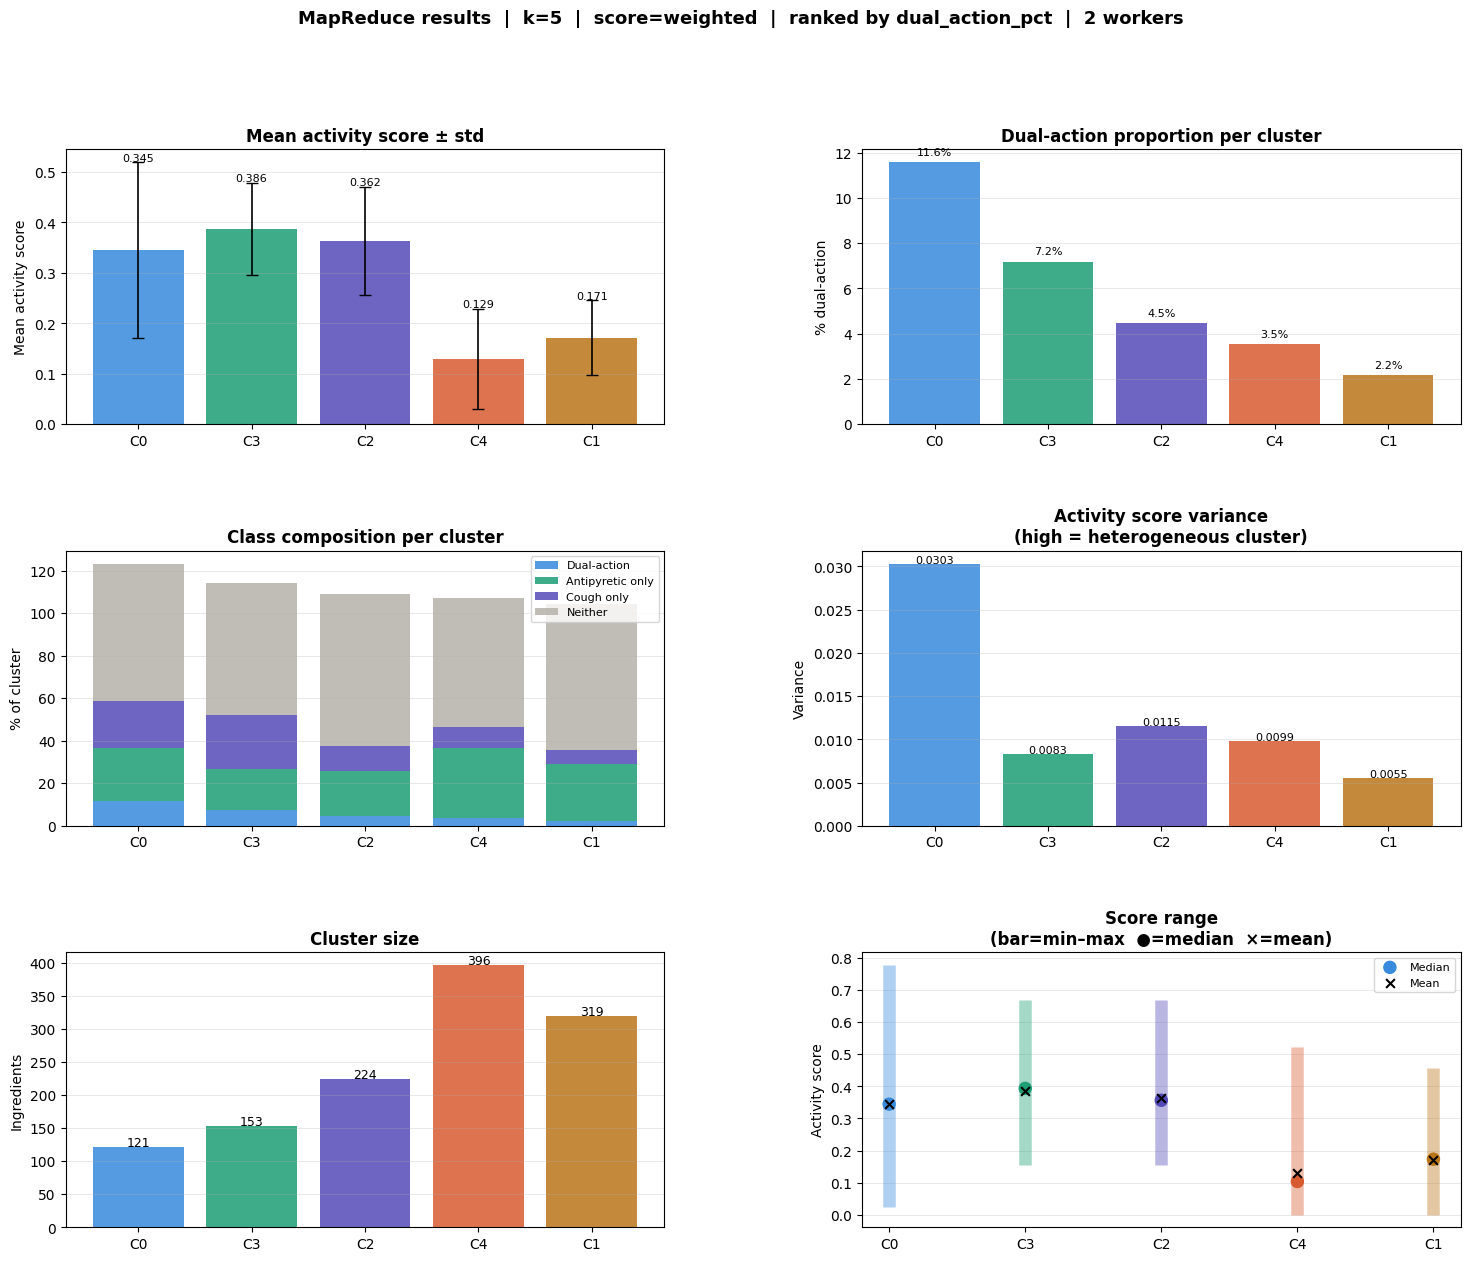

In [ ]:

# cell 51 — Full results dashboard  (6 panels)

cids   = summary_df["cluster_id"].astype(str).tolist()
x      = np.arange(len(cids))
c_bars = [PALETTE[i % len(PALETTE)] for i in range(len(cids))]

fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.46, wspace=0.33)
fig.suptitle(
    f"MapReduce results  |  k={N_CLUSTERS}  |  "
    f"score={SCORE_METHOD}  |  ranked by {RANK_BY}  |  "
    f"{N_WORKERS} workers",
    fontsize=13, fontweight="bold",
)

# Panel 1 — Mean score ± std
ax1   = fig.add_subplot(gs[0, 0])
means = summary_df["mean_score"].values
stds  = summary_df["std_score"].values
bars  = ax1.bar(x, means, color=c_bars, alpha=0.85,
                yerr=stds, capsize=4,
                error_kw={"linewidth": 1.2})
for bar, v, s in zip(bars, means, stds):
    ax1.text(bar.get_x()+bar.get_width()/2,
             v+s+0.003, f"{v:.3f}", ha="center", fontsize=8)
ax1.set_xticks(x); ax1.set_xticklabels([f"C{c}" for c in cids])
ax1.set_ylabel("Mean activity score")
ax1.set_title("Mean activity score ± std", fontweight="bold")
ax1.grid(axis="y", linewidth=0.4, alpha=0.5)

# Panel 2 — Dual-action %
ax2 = fig.add_subplot(gs[0, 1])
dp  = summary_df["dual_action_pct"].values
bars2 = ax2.bar(x, dp, color=c_bars, alpha=0.85)
for bar, v in zip(bars2, dp):
    ax2.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.3, f"{v:.1f}%",
             ha="center", fontsize=8)
ax2.set_xticks(x); ax2.set_xticklabels([f"C{c}" for c in cids])
ax2.set_ylabel("% dual-action")
ax2.set_title("Dual-action proportion per cluster",
              fontweight="bold")
ax2.grid(axis="y", linewidth=0.4, alpha=0.5)

# Panel 3 — Stacked class composition
ax3    = fig.add_subplot(gs[1, 0])
bottom = np.zeros(len(cids))
for label, col, color in [
    ("Dual-action",     "dual_action_pct",  "#378ADD"),
    ("Antipyretic only","antipyretic_pct",  "#1D9E75"),
    ("Cough only",      "cough_pct",        "#534AB7"),
    ("Neither",         "neither_pct",      "#B4B2A9"),
]:
    vals = summary_df[col].values
    ax3.bar(x, vals, bottom=bottom, label=label,
            color=color, alpha=0.85)
    bottom += vals
ax3.set_xticks(x); ax3.set_xticklabels([f"C{c}" for c in cids])
ax3.set_ylabel("% of cluster")
ax3.set_title("Class composition per cluster",
              fontweight="bold")
ax3.legend(fontsize=8); ax3.grid(axis="y", linewidth=0.4, alpha=0.5)

# Panel 4 — Variance
ax4   = fig.add_subplot(gs[1, 1])
vvals = summary_df["variance"].values
bars4 = ax4.bar(x, vvals, color=c_bars, alpha=0.85)
for bar, v in zip(bars4, vvals):
    ax4.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+0.00005, f"{v:.4f}",
             ha="center", fontsize=8)
ax4.set_xticks(x); ax4.set_xticklabels([f"C{c}" for c in cids])
ax4.set_ylabel("Variance")
ax4.set_title("Activity score variance\n"
              "(high = heterogeneous cluster)",
              fontweight="bold")
ax4.grid(axis="y", linewidth=0.4, alpha=0.5)

# Panel 5 — Cluster size
ax5   = fig.add_subplot(gs[2, 0])
sizes = summary_df["n_ingredients"].values
bars5 = ax5.bar(x, sizes, color=c_bars, alpha=0.85)
for bar, v in zip(bars5, sizes):
    ax5.text(bar.get_x()+bar.get_width()/2,
             bar.get_height()+1, str(v),
             ha="center", fontsize=9)
ax5.set_xticks(x); ax5.set_xticklabels([f"C{c}" for c in cids])
ax5.set_ylabel("Ingredients")
ax5.set_title("Cluster size", fontweight="bold")
ax5.grid(axis="y", linewidth=0.4, alpha=0.5)

# Panel 6 — Score range
ax6  = fig.add_subplot(gs[2, 1])
mins = summary_df["min_score"].values
maxs = summary_df["max_score"].values
meds = summary_df["median_score"].values
ax6.vlines(x, mins, maxs, color=c_bars, linewidth=9, alpha=0.4)
ax6.scatter(x, meds,  color=c_bars, s=75, zorder=5, label="Median")
ax6.scatter(x, means, color="black", s=40, marker="x",
            zorder=6, label="Mean")
ax6.set_xticks(x); ax6.set_xticklabels([f"C{c}" for c in cids])
ax6.set_ylabel("Activity score")
ax6.set_title("Score range\n(bar=min–max  ●=median  ×=mean)",
              fontweight="bold")
ax6.legend(fontsize=8); ax6.grid(axis="y", linewidth=0.4, alpha=0.5)

plt.savefig("mapreduce_dashboard.png", dpi=150, bbox_inches="tight")
plt.show()

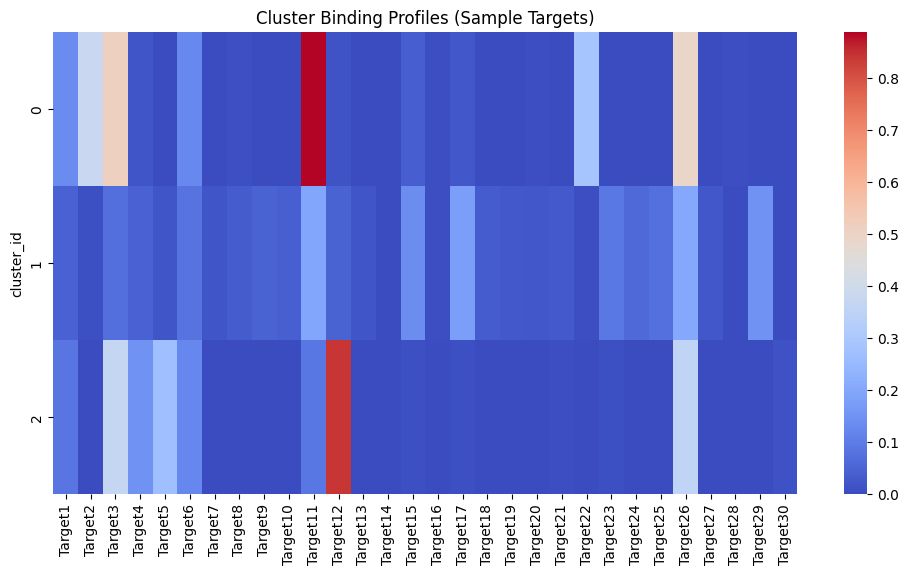

In [ ]:
#Cell 52- Cluster Binding Profiles
cluster_profiles = df.groupby("cluster_id")[target_cols].mean()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
sns.heatmap(cluster_profiles.iloc[:, :30], cmap="coolwarm")  # first 30 targets
plt.title("Cluster Binding Profiles (Sample Targets)")
plt.show()

In [ ]:
# Cell 53- cluster profiles
for c in sorted(cluster_profiles.index.unique()):
    print(f"\nCluster {c} top targets:")
    display(cluster_profiles.loc[c].sort_values(ascending=False).head(10))


Cluster 0 top targets:


,0
Target147,0.914474
Target227,0.891447
Target11,0.888158
Target51,0.878289
Target355,0.792763
Target208,0.779605
Target308,0.707237
Target149,0.634868
Target336,0.565789
Target116,0.562500



Cluster 1 top targets:


,1
Target66,0.580952
Target278,0.465079
Target280,0.444444
Target175,0.409524
Target229,0.380952
Target156,0.365079
Target378,0.360317
Target189,0.360317
Target230,0.347619
Target228,0.333333



Cluster 2 top targets:


,2
Target109,0.978495
Target51,0.956989
Target66,0.942652
Target49,0.910394
Target194,0.849462
Target12,0.842294
Target86,0.810036
Target147,0.688172
Target332,0.666667
Target293,0.612903


In [ ]:
display(summary_df)

,rank,cluster_id,n_ingredients,mean_score,median_score,std_score,variance,min_score,max_score,mean_score_norm,...,n_cough,n_neither,dual_action_pct,antipyretic_pct,cough_pct,neither_pct,workers_involved,rank_score,ci_lower,ci_upper
0,1,0,121,0.344638,0.344464,0.174058,0.030296,0.025609,0.778409,0.423790,...,27,78,11.570248,24.793388,22.314050,64.462810,2,5.882456,0.003484,0.685792
1,2,3,153,0.386036,0.393512,0.091363,0.008347,0.156282,0.667506,0.449420,...,39,95,7.189542,19.607843,25.490196,62.091503,2,3.708913,0.206964,0.565108
2,3,2,224,0.362396,0.356606,0.107352,0.011524,0.153680,0.668899,0.405102,...,26,160,4.464286,21.428571,11.607143,71.428571,2,2.338557,0.151986,0.572806
3,4,4,396,0.128865,0.103581,0.099304,0.009861,0.000000,0.522303,0.246725,...,39,241,3.535354,32.828283,9.848485,60.858586,2,1.804364,-0.065770,0.323500
4,5,1,319,0.170978,0.173111,0.074181,0.005503,0.000000,0.458148,0.373193,...,21,219,2.194357,26.959248,6.583072,68.652038,2,1.147371,0.025583,0.316372


Worker performance:
 worker_id  n_processed  mean_score  n_dual  n_clusters_covered  dual_pct  throughput
         0          611    0.311878      29                   5      4.75      1628.5
         1          602    0.297016      27                   5      4.49      1604.5


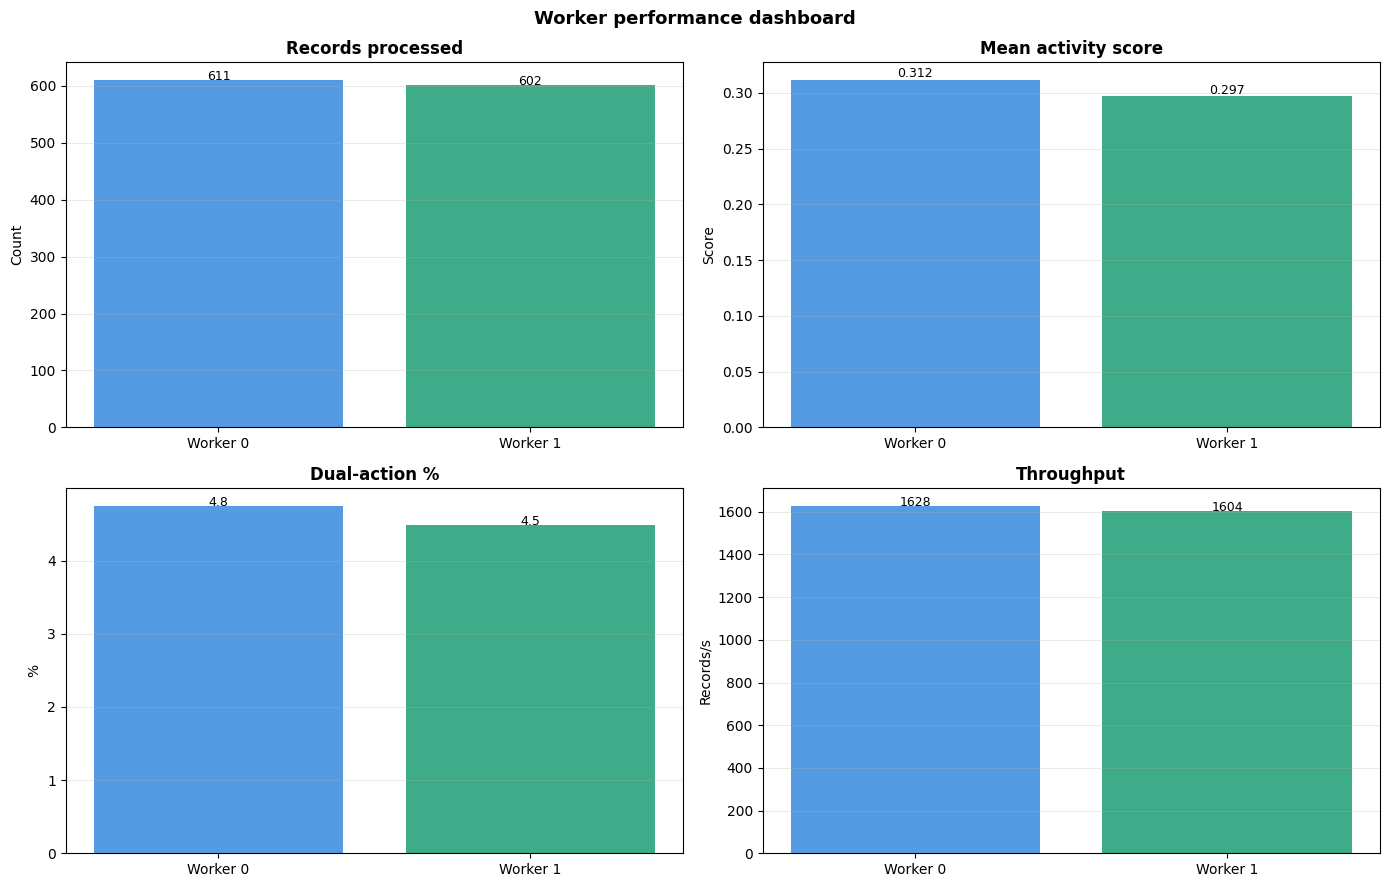

In [ ]:

# Cell 54 — Worker performance dashboard  (4 panels)


ingredient_df = pd.DataFrame(map_records).sort_values(
    ["cluster_id","activity_score_norm"],
    ascending=[True, False]
).reset_index(drop=True)

ingredient_df["class_label"] = ingredient_df.apply(
    lambda r: "dual_action"      if r["is_dual"]        == 1
         else "antipyretic_only" if r["is_antipyretic"] == 1
         else "cough_only"       if r["is_cough"]       == 1
         else "neither", axis=1
)

worker_stats = (
    ingredient_df.groupby("worker_id")
    .agg(
        n_processed        = ("ingredient",          "count"),
        mean_score         = ("activity_score_norm", "mean"),
        n_dual             = ("is_dual",             "sum"),
        n_clusters_covered = ("cluster_id",          "nunique"),
    ).reset_index()
)
worker_stats["dual_pct"]   = (
    worker_stats["n_dual"] / worker_stats["n_processed"] * 100).round(2)
worker_stats["throughput"] = (
    worker_stats["n_processed"] / map_time).round(1)

print("Worker performance:")
print(worker_stats.to_string(index=False))

wids     = worker_stats["worker_id"].astype(str)
w_colors = [PALETTE[i % len(PALETTE)] for i in range(len(wids))]
xwp      = np.arange(len(wids))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.suptitle("Worker performance dashboard",
             fontsize=13, fontweight="bold")

for ax, col, title, ylabel, fmt in [
    (axes[0,0], "n_processed",  "Records processed",   "Count",     "{:.0f}"),
    (axes[0,1], "mean_score",   "Mean activity score", "Score",     "{:.3f}"),
    (axes[1,0], "dual_pct",     "Dual-action %",       "%",         "{:.1f}"),
    (axes[1,1], "throughput",   "Throughput",          "Records/s", "{:.0f}"),
]:
    b = ax.bar(xwp, worker_stats[col], color=w_colors, alpha=0.85)
    for bar, v in zip(b, worker_stats[col]):
        ax.text(bar.get_x()+bar.get_width()/2,
                bar.get_height()+0.002,
                fmt.format(v), ha="center", fontsize=9)
    ax.set_xticks(xwp)
    ax.set_xticklabels([f"Worker {w}" for w in wids])
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontweight="bold")
    ax.grid(axis="y", linewidth=0.4, alpha=0.5)

plt.tight_layout()
plt.savefig("worker_performance.png", dpi=150, bbox_inches="tight")
plt.show()

ingredient_df.to_csv("mapreduce_ingredient_records.csv", index=False)

almost perfect chunks creation

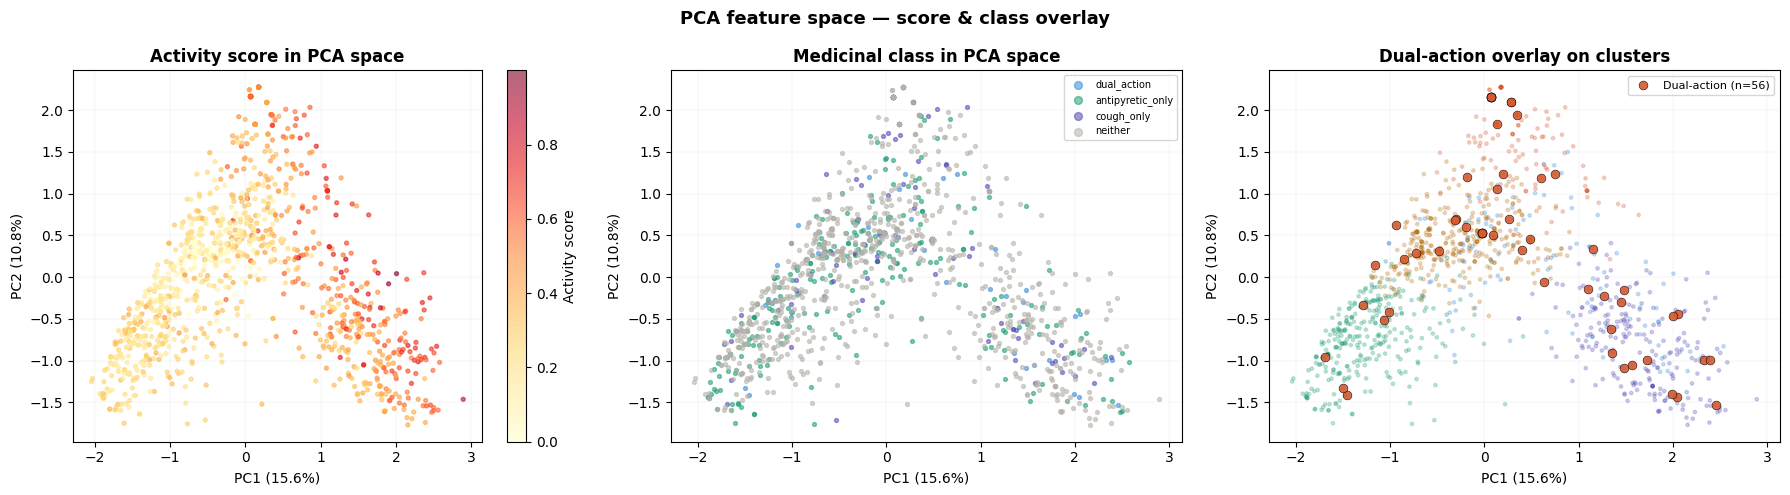

In [ ]:

# Cell 55 — PCA cluster-score heatmap
#            Shows where high-scoring and dual-action
#            ingredients sit in the 2-D feature space


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("PCA feature space — score & class overlay",
             fontsize=13, fontweight="bold")

# Scatter coloured by activity score
ax = axes[0]
sc = ax.scatter(X_pca[:, 0], X_pca[:, 1],
                c=activity_scores, cmap="YlOrRd",
                s=8, alpha=0.6)
plt.colorbar(sc, ax=ax, label="Activity score")
ax.set_xlabel(f"PC1 ({var_ex[0]:.1f}%)")
ax.set_ylabel(f"PC2 ({var_ex[1]:.1f}%)")
ax.set_title("Activity score in PCA space", fontweight="bold")
ax.grid(linewidth=0.3, alpha=0.3)

# Scatter coloured by medicinal class
ax2 = axes[1]
for cls, color in zip(class_order, class_colors):
    mask = mask_dict[cls]
    ax2.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=color, s=8, alpha=0.55, label=cls)
ax2.set_xlabel(f"PC1 ({var_ex[0]:.1f}%)")
ax2.set_ylabel(f"PC2 ({var_ex[1]:.1f}%)")
ax2.set_title("Medicinal class in PCA space", fontweight="bold")
ax2.legend(fontsize=7, markerscale=2)
ax2.grid(linewidth=0.3, alpha=0.3)

# Dual-action highlighted on cluster background
ax3 = axes[2]
ax3.scatter(X_pca[:, 0], X_pca[:, 1],
            c=[PALETTE[c % len(PALETTE)] for c in cluster_labels],
            s=6, alpha=0.25)
dual_mask = y_dual == 1
ax3.scatter(X_pca[dual_mask, 0], X_pca[dual_mask, 1],
            c="#D85A30", s=40, alpha=0.9,
            label=f"Dual-action (n={dual_mask.sum()})",
            edgecolors="black", linewidth=0.4, zorder=5)
ax3.set_xlabel(f"PC1 ({var_ex[0]:.1f}%)")
ax3.set_ylabel(f"PC2 ({var_ex[1]:.1f}%)")
ax3.set_title("Dual-action overlay on clusters",
              fontweight="bold")
ax3.legend(fontsize=8)
ax3.grid(linewidth=0.3, alpha=0.3)

plt.tight_layout()
plt.savefig("pca_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

higher scoring ingredients are scored higher corresponding to certain clusters , but medical clusters are distributed across the plot

In [ ]:
# Cell 56 — Final summary + download

from google.colab import files as colab_files

print("=" * 56)
print("  FINAL PIPELINE SUMMARY")
print("=" * 56)
print("\nThis analysis aimed to identify target-binding profiles that predict dual antipyretic + cough-suppressing activity and to cluster ingredients based on these profiles.\n")
print("**Key Findings:**\n")
print("1.  **Data Pre-processing:** Two datasets were merged, creating 4-class labels (dual-action, antipyretic-only, cough-only, neither). Zero-variance features were removed, leaving 379 target columns, with significant class imbalance noted, particularly for dual-action ingredients.\n")
print("2.  **K-Means Clustering:** Optimal `k` was assessed using elbow and silhouette methods, with `k=5` chosen for the final clustering. PCA visualization showed clusters that group ingredients by target similarity.\n")
print("3.  **Decision Tree Classification:** A Decision Tree, incorporating SMOTE for class imbalance, was trained to classify ingredients into the 4 medicinal classes. Feature selection reduced the dimensionality from 379 to 74 key features. The model identified top features (e.g., Target98, Target175, Target194) and achieved moderate macro F1 scores (e.g., ~0.31 on the test set for the 70/30 split), indicating some predictive capability despite the complex, imbalanced nature of the data.\n")
print("4.  **Linear Regression:** An activity score, weighted by the Decision Tree's feature importances, was constructed. A linear regression model was built to predict this score using the selected features. The model showed very high R² values, particularly when using a larger number of features (e.g., `k=24`), suggesting a strong relationship between the identified targets and the composite activity score, although potential in-sample dependency was noted.\n")
print("5.  **MapReduce Parallel Cluster Scoring:** A parallel processing pipeline was implemented to score and rank clusters based on various criteria. With `k=5` clusters, the pipeline successfully identified and ranked clusters based on 'dual_action_pct', highlighting the cluster with the highest proportion of dual-action ingredients (Cluster 0, with ~11.57% dual-action ingredients) as the top performer.\n")
print("In summary, the analysis successfully leveraged clustering, classification, and regression techniques to identify critical biological targets and ingredient clusters associated with dual antipyretic and cough-suppressing activity, providing a structured approach to identifying promising pharmaceutical compounds.\n")
print(f"  Workers               : {N_WORKERS}")
print(f"  Clusters              : {N_CLUSTERS}")
print(f"  Score method          : {SCORE_METHOD}")
print(f"  Ranked by             : {RANK_BY}")
print(f"  Ingredients processed : {len(map_records)}")
print(f"  Map time              : {map_time:.3f}s")
print(f"  Reduce time           : {reduce_time:.3f}s")
print(f"  Total time            : {map_time+reduce_time:.3f}s")
top = summary_df.iloc[0]
print(f"\n  Best cluster          : Cluster {int(top['cluster_id'])}")
print(f"  Rank                  : {int(top['rank'])}")
print(f"  Mean score            : {top['mean_score']:.4f}")
print(f"  Dual-action %         : {top['dual_action_pct']:.2f}%")
print(f"  Size                  : {int(top['n_ingredients'])} ingredients")
print("=" * 56)

print("\nAttempting to download files directly...")
for fname in [
    "cluster_analysis.png",
    "activity_score_distribution.png",
    "shard_balance.png",
    "mapreduce_dashboard.png",
    "worker_performance.png",
    "pca_overlay.png",
    "mapreduce_cluster_summary.csv",
    "mapreduce_ingredient_records.csv",
]:
    try:
        colab_files.download(fname)
        print(f"  Downloaded: {fname}")
    except Exception as e:
        print(f"  Failed to download {fname}: {e}. You can download it manually.")

print("\nAll files should now be available.")
print("If direct download prompts did not appear, you can find these files in the Colab file browser (left-hand sidebar, folder icon) and download them manually.")
print("Alternatively, you can save them to Google Drive for easier access by uncommenting and running the Google Drive integration code below.")

# # --- Optional: Save to Google Drive ---
# # Uncomment and run this section if direct downloads are not working.
# from google.colab import drive
# import os

# try:
#     drive.mount('/content/drive')
#     drive_path = '/content/drive/MyDrive/Colab_Output_MapReduce'
#     os.makedirs(drive_path, exist_ok=True)
#     print(f"\nSaving files to Google Drive: {drive_path}")
#     for fname in [
#         "cluster_analysis.png",
#         "activity_score_distribution.png",
#         "shard_balance.png",
#         "mapreduce_dashboard.png",
#         "worker_performance.png",
#         "pca_overlay.png",
#         "mapreduce_cluster_summary.csv",
#         "mapreduce_ingredient_records.csv",
#     ]:
#         shutil.copy(fname, drive_path)
#         print(f"  Copied {fname} to Google Drive.")
#     print("All files saved to Google Drive.")
# except Exception as e:
#     print(f"\nFailed to save files to Google Drive: {e}")

  FINAL PIPELINE SUMMARY

This analysis aimed to identify target-binding profiles that predict dual antipyretic + cough-suppressing activity and to cluster ingredients based on these profiles.

**Key Findings:**

1.  **Data Pre-processing:** Two datasets were merged, creating 4-class labels (dual-action, antipyretic-only, cough-only, neither). Zero-variance features were removed, leaving 379 target columns, with significant class imbalance noted, particularly for dual-action ingredients.

2.  **K-Means Clustering:** Optimal `k` was assessed using elbow and silhouette methods, with `k=5` chosen for the final clustering. PCA visualization showed clusters that group ingredients by target similarity.

3.  **Decision Tree Classification:** A Decision Tree, incorporating SMOTE for class imbalance, was trained to classify ingredients into the 4 medicinal classes. Feature selection reduced the dimensionality from 379 to 74 key features. The model identified top features (e.g., Target98, Target

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: cluster_analysis.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  Downloaded: mapreduce_cluster_summary.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  Downloaded: mapreduce_ingredient_records.csv

All files should now be available.
If direct download prompts did not appear, you can find these files in the Colab file browser (left-hand sidebar, folder icon) and download them manually.
Alternatively, you can save them to Google Drive for easier access by uncommenting and running the Google Drive integration code below.


the pipeline successfully identified critical biological targets and ingredient clusters that are associated with dual antipyretic and cough-suppressing activity, offering a structured approach to discover promising pharmaceutical compounds.

In conclusion, the analysis successfully identified specific biological targets  as strong predictors of dual activity. Furthermore, by clustering ingredients, Cluster 0 was identified as the best performing cluster  exhibiting the highest instances  of dual-action pharmaceutical ingredients .

In [ ]:
import os

# Ensure all files are staged, including newly created ones
!git add .

# Commit changes with a descriptive message
!git commit -m "Upload analysis results and generated plots"

# Push changes to the main branch
# The 'token' variable should still be available from previous execution
!git push https://{token}@github.com/Katerinachristopoulou/Data_mining.git main

On branch main
Your branch is up to date with 'origin/main'.

nothing to commit, working tree clean
Everything up-to-date


In [ ]:
import os
import shutil

# Define the list of generated files to move
generated_files = [
    "elbow_silhouette.png",
    "split_comparison.png",
    "pruning_path.png",
    "confusion_matrices.png",
    "feature_importance.png",
    "decision_tree_plot.png",
    "cv_stability.png",
    "decision_rules_full.txt",
    "coefficient_ranking.csv",
    "dimensionality_comparison.png",
    "actual_vs_predicted.png",
    "residual_plot.png",
    "regression_summary.csv",
    "decision_tree_importance_k_features.png",
    "cluster_analysis.png",
    "activity_score_distribution.png",
    "shard_balance.png",
    "mapreduce_dashboard.png",
    "worker_performance.png",
    "pca_overlay.png",
    "mapreduce_cluster_summary.csv",
    "mapreduce_ingredient_records.csv",

]

# Define the destination directory (your cloned repository)
repo_dir = "/content/Data_mining"

# Create the 'outputs' subdirectory if it doesn't exist
output_subdir = os.path.join(repo_dir, "outputs")
os.makedirs(output_subdir, exist_ok=True)

print(f"Moving generated files to {output_subdir}...")
for fname in generated_files:
    source_path = os.path.join("/content", fname)
    destination_path = os.path.join(output_subdir, fname)
    if os.path.exists(source_path):
        shutil.move(source_path, destination_path)
        print(f"  Moved: {fname}")
    else:
        print(f"  Skipped: {fname} (not found)")

print("Files moved successfully.")

In [ ]:
# Change to the repository directory
%cd /content/Data_mining

# Add all new/modified files in the 'outputs' subdirectory
!git add outputs/*

# Commit changes with a descriptive message
!git commit -m "Upload analysis results and generated plots to outputs folder"

# Push changes to the main branch
# The 'token' variable should still be available from previous execution
# If it's not, you'll need to re-enter your GitHub token in a previous cell.
!git push https://{token}@github.com/Katerinachristopoulou/Data_mining.git main

In [ ]:
import os
import shutil

# Define the list of generated files to move
generated_files = [
    "elbow_silhouette.png",
    "split_comparison.png",
    "pruning_path.png",
    "confusion_matrices.png",
    "feature_importance.png",
    "decision_tree_plot.png",
    "cv_stability.png",
    "decision_rules_full.txt",
    "coefficient_ranking.csv",
    "dimensionality_comparison.png",
    "actual_vs_predicted.png",
    "residual_plot.png",
    "regression_summary.csv",
    "decision_tree_importance_k_features.png",
    "cluster_analysis.png",
    "activity_score_distribution.png",
    "shard_balance.png",
    "mapreduce_dashboard.png",
    "worker_performance.png",
    "pca_overlay.png",
    "mapreduce_cluster_summary.csv",
    "mapreduce_ingredient_records.csv",

]

# Define the destination directory (your cloned repository)
repo_dir = "/content/Data_mining"

# Create the 'outputs' subdirectory if it doesn't exist
output_subdir = os.path.join(repo_dir, "outputs")
os.makedirs(output_subdir, exist_ok=True)

print(f"Moving generated files to {output_subdir}...")
for fname in generated_files:
    source_path = os.path.join("/content", fname)
    destination_path = os.path.join(output_subdir, fname)
    if os.path.exists(source_path):
        shutil.move(source_path, destination_path)
        print(f"  Moved: {fname}")
    else:
        print(f"  Skipped: {fname} (not found)")

print("Files moved successfully.")

In [ ]:
# Change to the repository directory
%cd /content/Data_mining

# Add all new/modified files in the 'outputs' subdirectory
!git add outputs/*

# Commit changes with a descriptive message
!git commit -m "Upload analysis results and generated plots to outputs folder"

# Push changes to the main branch
# The 'token' variable should still be available from previous execution
# If it's not, you'll need to re-enter your GitHub token in a previous cell.
!git push https://{token}@github.com/Katerinachristopoulou/Data_mining.git main